# EDA UCI-THYROID-DXBIN

Notebook: análise descritiva e exploratória do dataset UCI-THYROID-DXBIN. Execute todas as células para gerar os artefatos em `../eda_reports/` (subpastas: `csv`, `images`, `pdf`).

In [27]:
# Configura caminhos e imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from fpdf import FPDF

# Global output settings
OUTPUT_DPI = 800  # change this value to control DPI for all saved images
PDF_FILENAME = 'EDA_UCI-THYROID-DXBIN_report.v1.pdf'
DUPLICATE_ROWS = None
LINHAS_INICIAIS = None
COLUNAS_INICIAIS = None
BASE = os.path.join('..','')
RAW = os.path.join('..','data','raw')
PROCESSED = os.path.join('..','data','processed')
IMAGES = os.path.join('..','eda_reports','images')
CSV_DIR = os.path.join('..','eda_reports','csv')
PDF_DIR = os.path.join('..','eda_reports','pdf')
os.makedirs(IMAGES, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PDF_DIR, exist_ok=True)
EXCLUDE_COLUMNS = ['__cls_tmp__', 'y', 'orig_index', 'diagnosis','id', 'ID', 'patient_id', 'pid', 'fold', 'y_train', 'prob_0', 'prob_1', 'y_proba', 'y_pred','target','target_']
COLS_TO_REMOVE_LITERATURE = [] 
COLS_TO_REMOVE_MISSING = ['TBG']
COLS_TO_INPUTATION = ['sex', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
# Ajustes visuais
sns.set(style='whitegrid')

In [28]:
# Carrega dataset - ajusta automaticamente se houver um CSV em data/raw ou em eda_reports/csv
fn_raw = [f for f in os.listdir(RAW) if f.lower().endswith('.csv')]
if len(fn_raw) == 0:
    raise FileNotFoundError(f'Nenhum CSV encontrado em {RAW}. Coloque o uci_thyroid_dxbin.csv em data/raw e reexecute.')
csv_path = os.path.join(RAW, fn_raw[0])  # corrigido: usar fn_raw em vez de fn
print('Carregando:', csv_path)
# Leitura defensiva: tenta inferir separador e encoding simples
try:
    df = pd.read_csv(csv_path, sep=';',  encoding='utf-8')
except Exception:
    # tenta com sep=';' como fallback
    df = pd.read_csv(csv_path, sep=',')

#identifica duplicidades , grava arquivo de duplicadaos e remove duplicados do dataset 
LINHAS_INICIAIS = df.shape[0]
COLUNAS_INICIAIS = df.shape[1]

# Colunas consideradas para a checagem de duplicidade
cols_consider = [c for c in df.columns if c not in set(EXCLUDE_COLUMNS)]

if len(cols_consider) == 0:
    DUPLICATE_ROWS = df.duplicated(keep='first')
else:
    DUPLICATE_ROWS = df.duplicated(subset=cols_consider, keep='first')

#identifica duplicidades , grava arquivo de duplicadaos e remove duplicados do dataset 
if DUPLICATE_ROWS.sum() > 0:
    print(f'Encontradas {DUPLICATE_ROWS.sum()} linhas DUPLICATE_ROWS. Gravando arquivo de DUPLICATE_ROWS e removendo do dataset.')
    df[DUPLICATE_ROWS].to_csv(os.path.join(CSV_DIR, 'DUPLICATE_ROWS.csv'), index=False)
    df = df[~DUPLICATE_ROWS]
    print('Novas dimensões após remoção de duplicados:', df.shape)

colunas_str = "sex on_thyroxine query_on_thyroxine on_antithyroid_meds sick pregnant thyroid_surgery I131_treatment query_hypothyroid query_hyperthyroid lithium goitre tumor hypopituitary psych TSH_measured T3_measured FTI_measured TBG_measured TT4_measured T3_measured T4U_measured target"
array_fit_capt = colunas_str.split()
for col in array_fit_capt:
    df[col] = df[col].str.upper()

# Exibe dimensões e tipos
print('Dimensões:', df.shape)
display(df.head())

Carregando: ../data/raw/uci_thyroid_dxbin.csv
Encontradas 10 linhas DUPLICATE_ROWS. Gravando arquivo de DUPLICATE_ROWS e removendo do dataset.
Novas dimensões após remoção de duplicados: (9162, 31)
Dimensões: (9162, 31)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,F,F,F,F,F,F,F,T,...,NaN,F,NaN,F,NaN,F,NaN,other,-,840801013
1,29,F,F,F,F,F,F,F,F,F,...,128.0,F,NaN,F,NaN,F,NaN,other,-,840801014
2,41,F,F,F,F,F,F,F,F,F,...,NaN,F,NaN,F,NaN,T,11,other,-,840801042
3,36,F,F,F,F,F,F,F,F,F,...,NaN,F,NaN,F,NaN,T,26,other,-,840803046
4,32,F,F,F,F,F,F,F,F,F,...,NaN,F,NaN,F,NaN,T,36,other,S,840803047


In [29]:
# Helper cell: compute VIF values from numeric features (including binary 't'/'f') and save to CSV_DIR/vif_values.csv
# This allows the metrics cell to pick up VIFs without relying on external files.
import os
import numpy as np
import pandas as pd

try:
    # Resolve CSV_DIR fallback if missing
    try:
        CSV_DIR
    except NameError:
        try:
            CSV_DIR = os.path.join(BASE, 'eda_reports', 'csv') if 'BASE' in globals() and BASE else os.path.join('databases','UCI-THYROID-DXBIN','eda_reports','csv')
        except Exception:
            CSV_DIR = os.path.join('databases','UCI-THYROID-DXBIN','eda_reports','csv')
    os.makedirs(CSV_DIR, exist_ok=True)

    # Make a working copy and encode binary 't'/'f' style features
    df_enc = df.copy()

    def maybe_encode_binary_tf(series: pd.Series) -> pd.Series:
        if series.dtype == object:
            s = series.astype(str).str.strip().str.lower()
            uniq = set(s.dropna().unique())
            allowed = {'t','f','true','false','0','1'}
            if len(uniq) > 0 and uniq.issubset(allowed):
                mapped = s.map({'t':1, 'true':1, '1':1, 'f':0, 'false':0, '0':0})
                return pd.to_numeric(mapped, errors='coerce')
            # Try numeric coercion for numeric-like strings
            coerced = pd.to_numeric(series, errors='coerce')
            # If at least half are numeric after coercion, keep it
            if coerced.notna().sum() >= 0.5 * len(series):
                return coerced
        return series

    for c in df_enc.columns:
        try:
            df_enc[c] = maybe_encode_binary_tf(df_enc[c])
        except Exception:
            pass

    # Prepare numeric dataframe after encoding
    num_df = df_enc.select_dtypes(include=[np.number]).copy()

    # Drop probable target/ID columns if they exist
    for tgt in ['diagnosis', 'target', 'class']:
        if tgt in num_df.columns:
            num_df = num_df.drop(columns=[tgt])
    # Drop id-like columns (to avoid inflating VIF with identifiers)
    id_like = [c for c in num_df.columns if 'id' in c.lower()]
    if id_like:
        num_df = num_df.drop(columns=id_like)

    # Drop constant columns (zero variance)
    const_cols = [c for c in num_df.columns if num_df[c].nunique(dropna=True) <= 1]
    if const_cols:
        num_df = num_df.drop(columns=const_cols)

    # Only compute if we have at least 2 features
    if num_df.shape[1] >= 2:
        # Fill missing with median to enable VIF computation
        num_df = num_df.apply(lambda s: s.fillna(s.median()))
        try:
            from statsmodels.stats.outliers_influence import variance_inflation_factor
            X = num_df.values.astype(float)
            vif_vals = []
            for i in range(X.shape[1]):
                try:
                    val = float(variance_inflation_factor(X, i))
                except Exception:
                    val = float('inf')
                vif_vals.append(val)
            vif_s = pd.Series(vif_vals, index=num_df.columns, name='vif')
            # Save to CSV in the format the metrics cell expects (index + single column)
            vif_path = os.path.join(CSV_DIR, 'vif_values.csv')
            vif_s.to_frame().to_csv(vif_path)
            print(f'VIF salvo em: {vif_path} (features: {len(vif_s)})')
        except Exception as e:
            print('Não foi possível calcular VIF automaticamente (statsmodels ausente ou outro erro):', e)
    else:
        print('VIF não calculado: menos de 2 variáveis numéricas válidas após limpeza.')
except Exception as e:
    print('Erro inesperado ao calcular/salvar VIF:', e)

VIF salvo em: ../eda_reports/csv/vif_values.csv (features: 22)


In [30]:
# Ensure CSV_DIR is defined and directory exists (fallback)
import os

def save_fig(fig, fig_id, dpi=300):
    """
    Salva a figura (fig) no caminho especificado com a resolução (dpi).
    """
    path = os.path.join(IMAGES, fig_id)
    print(f"Salvando figura em {path}")
    # Usa fig.savefig do Matplotlib
    fig.savefig(path, format='png', dpi=dpi, bbox_inches='tight')

# Missingness summary: counts and percent - salva tabela e figura
missing_counts = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_df = pd.DataFrame({
    'nulos': [f"{int(v)} - {round((v/df.shape[0]*100) if df.shape[0]>0 else 0,1)}%" for v in missing_counts]
}, index=missing_counts.index)
missing_df = missing_df.sort_values(by='nulos', key=lambda s: s.apply(lambda x: int(str(x).split(' - ')[0])), ascending=False)
display(missing_df.head(50))
missing_df.to_csv(os.path.join(CSV_DIR, 'missing_summary.csv'))

# Heatmap of missing values (if not too large)
try:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
    ax.set_title('Missingness map (rows x cols)')
    save_fig(fig, 'missingness_matrix.png', dpi=OUTPUT_DPI)
    plt.close(fig)
except Exception as e:
    print('Não foi possível gerar missingness heatmap:', e)

# Utilitários: outliers (IQR), entropia para numérico/categórico
from math import log2

def iqr_outliers(series_num: pd.Series):
    s = series_num.dropna().astype(float)
    if s.empty:
        return 0, 0.0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0, 0.0
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    mask = (s < low) | (s > high)
    count = int(mask.sum())
    pct = (count / len(series_num) * 100.0) if len(series_num) else 0.0
    return count, pct

def entropy_feature(ser: pd.Series, max_bins: int = 20):
    """
    Calcula a entropia de Shannon (raw) e a entropia normalizada (0..1).
    - Numéricas: discretização em até `max_bins` bins.
    - Categóricas: frequências por categoria.
    Retorna: (entropia_raw, entropia_normalizada)
    """
    s = ser.dropna()
    if s.empty:
        return float('nan'), float('nan')
    # Numérica: discretiza por bins
    if pd.api.types.is_numeric_dtype(s):
        unique_vals = s.nunique(dropna=True)
        bins = min(max_bins, max(2, unique_vals))
        try:
            binned, _ = pd.cut(s, bins=bins, include_lowest=True, retbins=True, duplicates='drop')
            counts = binned.value_counts(dropna=False).values.astype(float)
        except Exception:
            counts = s.value_counts(dropna=False).values.astype(float)
    else:
        counts = s.astype(str).value_counts(dropna=False).values.astype(float)
    probs = counts / counts.sum()
    # Entropia de Shannon (raw)
    ent_raw = -np.sum([p*log2(p) for p in probs if p > 0])
    # Normalização por log2(k)
    k = len(counts)
    if k <= 1:
        return 0.0, 0.0
    ent_norm = float(ent_raw / log2(k))
    return float(ent_raw), ent_norm

# Mapear VIF para uma escala percentual (25%, 50%, 75%, 100%)
# 1 -> 25%, 5 -> 50%, 10 -> 75%, >10 -> 100%
def vif_to_percent(v):
    try:
        v = float(v)
    except Exception:
        return ''
    if np.isnan(v) or not np.isfinite(v):
        return ''
    if v <= 1:
        pct = 25.0
    elif v <= 5:
        pct = 25.0 + (v - 1.0) / 4.0 * 25.0
    elif v <= 10:
        pct = 50.0 + (v - 5.0) / 5.0 * 25.0
    else:
        pct = 100.0
    return pct

# --- Prepare metrics per feature ---
try:
    stats = []
    out_iqr_series = {}
    for c in df.columns:
        ser = df[c]
        ser_num = pd.to_numeric(ser, errors='coerce')

        # Estatísticas numéricas básicas (para variáveis numéricas)
        mean = ser_num.mean()
        std = ser_num.std()
        mn = ser_num.min()
        mx = ser_num.max()
        median = ser_num.median()
        n_total = ser.shape[0]
        n_nulls = int(ser.isna().sum())
        n_non_na_num = int(ser_num.notna().sum())

        # IC 95% da média (se aplicável)
        try:
            sem = (std / np.sqrt(n_non_na_num)) if n_non_na_num > 0 else float('nan')
            ic_low  = mean - 1.96*sem if pd.notna(sem) else float('nan')
            ic_high = mean + 1.96*sem if pd.notna(sem) else float('nan')
            ic95 = f'[{ic_low:.3f}, {ic_high:.3f}]' if pd.notna(sem) else '[]'
        except Exception:
            ic95 = '[]'

        coef_var = (std/mean) if mean and mean!=0 else float('nan')
        variance = std**2 if std==std else float('nan')

        # Moda: para colunas não numéricas, usar a moda categórica; caso numérica, usar moda numérica
        try:
            m_num = ser_num.dropna().mode()
        except Exception:
            m_num = pd.Series(dtype=float)
        try:
            m_cat = ser.dropna().mode()
        except Exception:
            m_cat = pd.Series(dtype=object)

        if n_non_na_num == 0 and len(m_cat) > 0:
            mode_val = m_cat.iloc[0]
        elif len(m_num) > 0:
            mode_val = m_num.iloc[0]
        elif len(m_cat) > 0:
            mode_val = m_cat.iloc[0]
        else:
            mode_val = ''  # sem moda ou somente NaN

        if pd.isna(mode_val):
            mode_val = ''

        # Outliers (IQR) e percentual – apenas para numéricas
        if n_non_na_num > 0:
            out_count, out_pct = iqr_outliers(ser_num)
            outlier_str = f"{out_count} - {round(out_pct,1)}%"
        else:
            out_count, out_pct = 0, 0.0
            outlier_str = "0 - 0.0%"
        out_iqr_series[c] = out_count

        # Entropia: valor raw e normalizado => formato "raw - pct%"
        ent_raw, ent_norm = entropy_feature(ser)
        if pd.isna(ent_raw) or pd.isna(ent_norm):
            ent_str = ''
        else:
            ent_str = f"{ent_raw:.5f} - {ent_norm*100:.1f}%"

        stats.append({
            'variable': c,
            'mean': mean,
            'std': std,
            'min': mn,
            'max': mx,
            'mediana': median,
            'ic_95': ic95,
            'coef_variacao': coef_var,
            'variancia': variance,
            'nulos': n_nulls,
            'moda': mode_val,
            'outlier': outlier_str,
            'entropy': ent_str
        })
    stats_df = pd.DataFrame(stats).set_index('variable')

    # VIF se existir arquivo auxiliar (mantido, mas não obrigatório)
    def safe_read_series(path, squeeze_col=0):
        try:
            if os.path.exists(path):
                ser = pd.read_csv(path, index_col=0)
                if ser.shape[1] >= 1:
                    return ser.iloc[:, squeeze_col]
                return ser.iloc[:,0]
        except Exception:
            pass
        return pd.Series(index=stats_df.index, data=[float('nan')]*len(stats_df))

    try:
        vif_path = os.path.join(CSV_DIR, 'vif_values.csv')
        vif_s = safe_read_series(vif_path)
    except Exception:
        vif_s = pd.Series(index=stats_df.index, data=[float('nan')]*len(stats_df))

    # Monta métricas
    metrics = stats_df.copy()
    # Aplica transformação ao VIF: "valor - pct%" (valor com 5 casas)
    vif_vals = [vif_s.get(c, float('nan')) if hasattr(vif_s, 'get') else float('nan') for c in metrics.index]
    def format_vif(v):
        try:
            vnum = float(v)
        except Exception:
            return ''
        if np.isnan(vnum) or not np.isfinite(vnum):
            return ''
        pct = vif_to_percent(vnum)
        if pct == '':
            return f"{vnum:.5f}"
        return f"{vnum:.5f} - {pct:.1f}%"
    metrics['vif'] = [format_vif(v) for v in vif_vals]

    # Formata 'nulos' como "qtd - percentual%"
    total_rows = df.shape[0]
    metrics['nulos'] = [
        f"{int(x)} - {((int(x)/total_rows*100) if total_rows else 0):.1f}%"
        for x in pd.to_numeric(metrics['nulos'], errors='coerce').fillna(0)
    ]

    # Normalidade (Shapiro e D'Agostino) – apenas para numéricas com dados
    from scipy.stats import shapiro, normaltest
    normal_shapiro_stat = {}
    normal_shapiro_p = {}
    normal_shapiro_result = {}
    normal_dagostino_stat = {}
    normal_dagostino_p = {}
    normal_dagostino_result = {}

    for c in metrics.index:
        try:
            series = pd.to_numeric(df[c], errors='coerce').dropna()
            n = len(series)
            if n == 0:
                normal_shapiro_stat[c] = float('nan')
                normal_shapiro_p[c] = float('nan')
                normal_shapiro_result[c] = 'Não - p ≤ 0.05 - 0,000'
                normal_dagostino_stat[c] = float('nan')
                normal_dagostino_p[c] = float('nan')
                normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'
                continue
            sample = series.sample(n=5000, random_state=0) if n > 5000 else series

            # Shapiro-Wilk
            try:
                s_stat, s_p = shapiro(sample)
                s_stat = float(s_stat)
                s_p = float(s_p)
                normal_shapiro_stat[c] = s_stat
                normal_shapiro_p[c] = s_p
                p_fmt = f"{s_p:.3f}" if (s_p==s_p) else "0.000"
                p_fmt_display = p_fmt.replace('.', ',')
                if s_p > 0.05:
                    normal_shapiro_result[c] = f"Sim - p > 0.05 - {p_fmt_display}"
                else:
                    normal_shapiro_result[c] = f"Não - p ≤ 0.05 - {p_fmt_display}"
            except Exception:
                normal_shapiro_stat[c] = float('nan')
                normal_shapiro_p[c] = float('nan')
                normal_shapiro_result[c] = 'Não - p ≤ 0.05 - 0,000'

            # D'Agostino K^2
            try:
                if len(sample) >= 8:
                    d_stat, d_p = normaltest(sample)
                    d_stat = float(d_stat)
                    d_p = float(d_p)
                    normal_dagostino_stat[c] = d_stat
                    normal_dagostino_p[c] = d_p
                    p_fmt = f"{d_p:.3f}" if (d_p==d_p) else "0.000"
                    p_fmt_display = p_fmt.replace('.', ',')
                    if d_p > 0.05:
                        normal_dagostino_result[c] = f"Sim - p > 0.05 - {p_fmt_display}"
                    else:
                        normal_dagostino_result[c] = f"Não - p ≤ 0.05 - {p_fmt_display}"
                else:
                    normal_dagostino_stat[c] = float('nan')
                    normal_dagostino_p[c] = float('nan')
                    normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'
            except Exception:
                normal_dagostino_stat[c] = float('nan')
                normal_dagostino_p[c] = float('nan')
                normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'

        except Exception:
            normal_shapiro_stat[c] = float('nan')
            normal_shapiro_p[c] = float('nan')
            normal_shapiro_result[c] = 'Não - p ≤ 0.05 - 0,000'
            normal_dagostino_stat[c] = float('nan')
            normal_dagostino_p[c] = float('nan')
            normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'

    # Build normality DataFrame and save
    normality_df = pd.DataFrame(index=metrics.index)
    normality_df['shapiro_stat'] = pd.Series(normal_shapiro_stat)
    normality_df['shapiro_p'] = pd.Series(normal_shapiro_p)
    normality_df['shapiro_result'] = pd.Series(normal_shapiro_result)
    normality_df['dagostino_stat'] = pd.Series(normal_dagostino_stat)
    normality_df['dagostino_p'] = pd.Series(normal_dagostino_p)
    normality_df['dagostino_result'] = pd.Series(normal_dagostino_result)

    try:
        normality_df.to_csv(os.path.join(CSV_DIR, 'normality_tests.csv'))
    except Exception as e:
        print('Falha ao salvar normality_tests.csv:', e)

    # Add normal results to metrics (detailed + aggregated)
    metrics['normal_shapiro'] = normality_df['shapiro_result']
    metrics['normal_shapiro_stat'] = normality_df['shapiro_stat']
    metrics['normal_shapiro_p'] = normality_df['shapiro_p']
    metrics['normal_dagostino'] = normality_df['dagostino_result']
    metrics['normal_dagostino_stat'] = normality_df['dagostino_stat']
    metrics['normal_dagostino_p'] = normality_df['dagostino_p']

    # Aggregated 'normal' decision
    normal_agg = []
    for c in metrics.index:
        s_res = metrics.at[c, 'normal_shapiro'] if 'normal_shapiro' in metrics.columns else 'Não - p ≤ 0.05 - 0,000'
        d_res = metrics.at[c, 'normal_dagostino'] if 'normal_dagostino' in metrics.columns else 'Não - p ≤ 0.05 - 0,000'
        try:
            s_p = metrics.at[c, 'normal_shapiro_p'] if pd.notnull(metrics.at[c, 'normal_shapiro_p']) else float('nan')
        except Exception:
            s_p = float('nan')
        try:
            d_p = metrics.at[c, 'normal_dagostino_p'] if pd.notnull(metrics.at[c, 'normal_dagostino_p']) else float('nan')
        except Exception:
            d_p = float('nan')
        s_is_sim = isinstance(s_res, str) and s_res.startswith('Sim')
        d_is_sim = isinstance(d_res, str) and d_res.startswith('Sim')
        if s_is_sim and d_is_sim:
            chosen_p = max([p for p in [s_p, d_p] if p==p], default=float('nan'))
            p_fmt = f"{chosen_p:.3f}" if (chosen_p==chosen_p) else "0.000"
            p_disp = p_fmt.replace('.', ',')
            normal_agg.append(f"Sim - p > 0.05 - {p_disp}")
        else:
            chosen_p = min([p for p in [s_p, d_p] if p==p], default=0.0)
            p_fmt = f"{chosen_p:.3f}" if (chosen_p==chosen_p) else "0.000"
            p_disp = p_fmt.replace('.', ',')
            normal_agg.append(f"Não - p ≤ 0.05 - {p_disp}")

    metrics['normal'] = normal_agg

    # drop helper column if present
    if 'percentual_nulos' in metrics.columns:
        metrics = metrics.drop(columns=['percentual_nulos'])

    # format numeric columns to 3 decimals (não incluir 'moda', 'nulos', 'entropy', 'vif' que agora são strings)
    numcols = ['mean','std','min','max','mediana','coef_variacao','variancia','normal_shapiro_stat','normal_shapiro_p','normal_dagostino_stat','normal_dagostino_p']
    for nc in numcols:
        if nc in metrics.columns:
            metrics[nc] = metrics[nc].apply(lambda x: round(x,3) if (pd.notnull(x) and isinstance(x,(int,float,np.floating))) else x)

    # save metrics CSV (NaN em branco)
    metrics.to_csv(os.path.join(CSV_DIR, 'feature_metrics_full.csv'), na_rep='')

    # render as wide table image (landscape) with smaller font; include 'entropy' and 'normal' columns
    rows_per_page = 60
    total_rows = metrics.shape[0]
    pages = (total_rows + rows_per_page - 1) // rows_per_page
    for p in range(pages):
        start = p*rows_per_page
        HIDE_COLS = ['normal_shapiro_stat','normal_shapiro_p','normal_dagostino_stat','normal_dagostino_p', 'normal_shapiro', 'normal_dagostino']
        tmp = metrics.reset_index()

        # 🔹 remove linhas onde a coluna 'variable' (ou índice) seja 'diagnosis'
        if 'variable' in tmp.columns:
            tmp = tmp[tmp['variable'] != 'diagnosis']
        else:
            tmp = tmp[tmp.index != 'diagnosis']

        tbl = tmp.drop(columns=[c for c in HIDE_COLS if c in tmp.columns]) \
                .iloc[start:start+rows_per_page]

        # Substituir NaN por string vazia para evitar 'nan' no PNG
        tbl_display = tbl.replace({np.nan: ''})

        fig, ax = plt.subplots(figsize=(13.0, 8.57))
        ax.axis('off')
        ax.set_title(f'Feature metrics (page {p+1}/{pages})', fontsize=12)
        # compute column widths to reduce whitespace for numeric columns
        cols = tbl_display.columns.tolist()
        # default width
        default_w = 0.08
        col_widths_map = {
            'variable': 0.12,
            'mean': 0.045,
            'std': 0.045,
            'min': 0.04,
            'max': 0.04,
            'mediana': 0.045,
            'ic_95': 0.12,
            'coef_variacao': 0.06,
            'nulos': 0.07,
            'vif': 0.13,
            'outlier': 0.07,
            'entropy': 0.13,
            'moda': 0.08,
            'normal': 0.11
        }
        widths = [col_widths_map.get(c, default_w) for c in cols]
        cell_text = [cols] + tbl_display.values.tolist()
        # create table with specified column widths
        table = ax.table(cellText=cell_text, loc='center', cellLoc='left', colWidths=widths)
        table.auto_set_font_size(False)
        table.set_fontsize(7)
        # slightly reduce vertical padding
        table.scale(1.0, 0.75)
        plt.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.02)
        save_fig(fig, f'metrics_landscape_page_{p+1}.png', dpi=OUTPUT_DPI)
        plt.close(fig)

except Exception as e:
    print('Failed to build metrics_landscape PNG:', e)

,nulos
TBG,8821 - 96.3%
T3,2596 - 28.3%
TSH,834 - 9.1%
T4U,801 - 8.7%
FTI,794 - 8.7%
TT4,434 - 4.7%
sex,306 - 3.3%
age,0 - 0.0%
TSH_measured,0 - 0.0%
target,0 - 0.0%


Salvando figura em ../eda_reports/images/missingness_matrix.png


/5_xAI/.xai/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/5_xAI/.xai/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/5_xAI/.xai/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/5_xAI/.xai/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/5_xAI/.xai/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/5_xAI/.xai/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/5_x

Salvando figura em ../eda_reports/images/metrics_landscape_page_1.png


In [31]:
#Remoção de colunas conforme referencias de literatura e devido a MISSING 
cols_to_remove = [col for col in COLS_TO_REMOVE_LITERATURE if col in df.columns]
if cols_to_remove:
    print('Removendo colunas conforme referencias de literatura:', cols_to_remove)
    df = df.drop(columns=cols_to_remove)
    print('Novas dimensões após remoção de colunas:', df.shape)     
    
cols_to_remove = [col for col in COLS_TO_REMOVE_MISSING if col in df.columns]
if cols_to_remove:
    print('Removendo colunas conforme referencias de missing:', cols_to_remove)
    df = df.drop(columns=cols_to_remove)
    print('Novas dimensões após remoção de colunas:', df.shape)    

df_copia = df.copy()

Removendo colunas conforme referencias de missing: ['TBG']
Novas dimensões após remoção de colunas: (9162, 30)


In [32]:
##Imputação de Dados UCI-THYROID-DXBIN com MICEForest ##########################
#
#   Imputação de Dados UCI-THYROID-DXBIN com MICEForest
#   - Corrige 'sex' com base em 'pregnant'
#   - Usa _RID para alinhamento e reset_index APENAS no input do kernel (exigência do miceforest)
#   - Saída final sem NaN
#
##################################################################################
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import miceforest as mf
from tqdm import tqdm

print("\n" + "="*80)
print("🔵 INICIANDO PROCESSO DE IMPUTAÇÃO FINAL (SEM NENHUM NaN)")
print("="*80)

# === CONFIGURAÇÕES ===
COLS_TO_INPUTATION = ['sex', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
NUMERIC_COLS       = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

# Diretórios
IMAGES_DIR = os.path.join(os.getcwd(), "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

# Se CSV_DIR não existir na sua sessão, descomente e ajuste:
# CSV_DIR = os.path.join(os.getcwd(), "csv")
os.makedirs(CSV_DIR, exist_ok=True)

# =========================
# COMPAT MICEFOREST x PANDAS
# =========================
import pandas as _pd
import numpy as _np
from miceforest import imputed_data as _mf_imputed_data

# 1) Corrige iteration_count para lidar com Series/Index sem MultiIndex adequado
if not hasattr(_mf_imputed_data.ImputedData, "_he_fix_iter_applied"):
    def _safe_iteration_count(self, dataset=None, variable=None):
        itab = _pd.Series(self.iteration_tab)
        # Garante MultiIndex (variable, dataset)
        if not isinstance(itab.index, _pd.MultiIndex):
            tuples = []
            for k in itab.index:
                if isinstance(k, tuple) and len(k) == 2:
                    tuples.append(k)
                else:
                    tuples.append((k, 0))
            itab.index = _pd.MultiIndex.from_tuples(tuples, names=["variable", "dataset"])
        else:
            itab.index = _pd.MultiIndex.from_tuples(list(itab.index), names=["variable", "dataset"])

        if itab.empty:
            return 0

        try:
            values = itab.loc[variable, dataset]
            arr = _np.unique(values)
            return int(arr.max()) if arr.size else 0
        except Exception:
            return 0

    _mf_imputed_data.ImputedData.iteration_count = _safe_iteration_count
    _mf_imputed_data.ImputedData._he_fix_iter_applied = True

# 2) Corrige __getitem__ para garantir colunas MultiIndex (iteration, dataset)
if not hasattr(_mf_imputed_data.ImputedData, "_he_fix_getitem_applied"):
    _orig_getitem = _mf_imputed_data.ImputedData.__getitem__

    def _safe_getitem(self, tup):
        variable, iteration, dataset = tup
        df_vals = self.imputation_values[variable]

        # Normaliza colunas para MultiIndex de 2 níveis (iteration, dataset)
        cols = df_vals.columns
        if not isinstance(cols, _pd.MultiIndex) or cols.nlevels != 2:
            try:
                # Tenta interpretar colunas como iterações e dataset=0
                new_cols = _pd.MultiIndex.from_tuples(
                    [ (int(c), 0) for c in cols ],
                    names=["iteration", "dataset"]
                )
            except Exception:
                # Se não forem inteiros, tenta mapear posição -> iteração
                new_cols = _pd.MultiIndex.from_tuples(
                    [ (i, 0) for i, _ in enumerate(cols) ],
                    names=["iteration", "dataset"]
                )
            df_vals.columns = new_cols
            cols = df_vals.columns
        else:
            # Garante nomes padronizados
            df_vals.columns = _pd.MultiIndex.from_tuples(list(cols), names=["iteration", "dataset"])
            cols = df_vals.columns

        # Seleciona chave disponível se (iteration, dataset) não existir
        key = (iteration, dataset)
        if key not in cols:
            # Preferir maior iteração do dataset solicitado
            same_ds = [c for c in cols if c[1] == dataset]
            if same_ds:
                best_it = max(c[0] for c in same_ds)
                key = (best_it, dataset)
            else:
                # Cai para maior iteração global (qualquer dataset)
                best_it = max(c[0] for c in cols)
                # pega algum dataset existente para essa iteração
                ds_for_it = [c[1] for c in cols if c[0] == best_it]
                key = (best_it, ds_for_it[0] if ds_for_it else 0)

        return df_vals.loc[:, key]

    _mf_imputed_data.ImputedData.__getitem__ = _safe_getitem
    _mf_imputed_data.ImputedData._he_fix_getitem_applied = True

# 🔵 1) Snapshot do DF original
df_before_imputation = df.copy()
linhas_iniciais = df.shape[0]
print(f"\n📄 Linhas iniciais: {linhas_iniciais}")

# 🔵 2) Correção de 'sex' baseada em 'pregnant'
if 'pregnant' in df.columns and 'sex' in df.columns:
    sex_raw = df['sex'].astype(str).str.strip().str.upper()
    mask_sex_missing = sex_raw.isna() | (sex_raw == '') | (sex_raw == '-') | (sex_raw == 'NAN') | (sex_raw == 'NONE')
    mask = (df['pregnant'].astype(str).str.lower() == 't') & mask_sex_missing
    corrected_count = mask.sum()
    df.loc[mask, 'sex'] = 'F'
    print(f"✅ {corrected_count} registros tiveram 'sex' corrigido para 'F' (pregnant == 't')")
else:
    print("⚠️ Colunas 'pregnant' ou 'sex' ausentes; pulando correção baseada em 'pregnant'.")

# 🔵 3) Preparação do subset para imputação
cols_to_impute = [c for c in COLS_TO_INPUTATION if c in df.columns]
if not cols_to_impute:
    raise ValueError("Nenhuma das colunas de imputação existe no dataframe.")

df_to_impute = df[cols_to_impute].copy()
df_to_impute['_RID'] = df.index

# Converte numéricos com segurança
for col in NUMERIC_COLS:
    if col in df_to_impute.columns:
        df_to_impute[col] = pd.to_numeric(df_to_impute[col], errors='coerce')

# Normaliza 'sex' -> {0,1} para o MICE
if 'sex' in df_to_impute.columns:
    sex_norm = (
        df_to_impute['sex']
        .astype(str).str.strip().str.upper()
        .replace({'': np.nan, '-': np.nan, 'NAN': np.nan, 'NONE': np.nan})
    )
    df_to_impute['sex'] = sex_norm.map({'M': 0, 'F': 1})

# 🔵 4) Executa MICEForest
# miceforest exige RangeIndex: resetamos o índice APENAS no input do kernel
aux_cols = ['_RID']
impute_input = df_to_impute.drop(columns=aux_cols).reset_index(drop=True)

print("\n🔵 Executando MICEForest (5 iterações, random_state=42)")
kernel = mf.ImputationKernel(data=impute_input, random_state=42)

for _ in tqdm(range(5), desc="MICE Iterações"):
    kernel.mice(1)

df_imputed = kernel.complete_data(0)

# Reanexa _RID pelo MESMO ORDENAMENTO usado no input (comprimento idêntico)
df_imputed[aux_cols] = df_to_impute[aux_cols].values

# 🔵 5) Pós-processamento de tipos
if 'sex' in df_imputed.columns:
    df_imputed['sex'] = pd.to_numeric(df_imputed['sex'], errors='coerce').round().clip(0, 1)
    df_imputed['sex'] = df_imputed['sex'].map({0.0: 'M', 1.0: 'F'}).astype('object')

# 🔵 6) Atualiza o DF original usando _RID
cols_update = [c for c in cols_to_impute if c in df_imputed.columns]
tmp_update = df_imputed[['_RID'] + cols_update].copy()

df_work = df.copy()
df_work['_RID'] = df_work.index

df_work = df_work.merge(tmp_update, on='_RID', how='left', suffixes=('', '__imputed'))

for c in cols_update:
    ic = f"{c}__imputed"
    if ic in df_work.columns:
        df_work[c] = df_work[ic]
        df_work.drop(columns=[ic], inplace=True)

df_work.drop(columns=['_RID'], inplace=True)

# 🔵 7) Remoção final de quaisquer NaNs (garantia de dataset 100% completo)
total_nans_before = df_work.isnull().sum().sum()
if total_nans_before > 0:
    df_clean = df_work.dropna().copy()
else:
    df_clean = df_work.copy()

linhas_finais = df_clean.shape[0]
linhas_removidas = linhas_iniciais - linhas_finais
pct_removidas = (linhas_removidas / linhas_iniciais * 100) if linhas_iniciais else 0.0
print(f"\n🗑️ Linhas removidas no total (para eliminar 100% dos NaN): {linhas_removidas} ({pct_removidas:.2f}%)")

# 🔵 8) Atualiza df global e salva CSV final
df = df_clean.copy()

output_csv = os.path.join(CSV_DIR, "uci_thyroid_dxbin_imputed_clean.csv")
df.to_csv(output_csv, index=False)
print(f"✅ Arquivo final salvo: {output_csv}")

# 🔵 9) Verificação de segurança
total_nans = df.isnull().sum().sum()
if total_nans == 0:
    print("\n🎯 Nenhum NaN restante! Dataset 100% completo.")
else:
    print(f"\n⚠️ Ainda existem {total_nans} NaNs — verifique colunas não numéricas/derivadas.")

# 🔵 10) Plot distribuições log10 antes vs depois — 3x4 por página (A4) com contraste e bins iguais
num_cols_presentes = [c for c in NUMERIC_COLS if c in df.columns]

if len(num_cols_presentes) > 0:
    print("\n📊 Gerando histogramas log10 (antes vs. depois) com contraste e bins iguais...")

    def _prep(s):
        s = pd.to_numeric(s, errors='coerce')
        gt0 = s[s > 0]
        return np.log10(gt0.dropna())

    before_log = {c: _prep(df_before_imputation[c]) for c in num_cols_presentes}
    after_log  = {c: _prep(df[c])                    for c in num_cols_presentes}

    per_page = 12
    pages = int(np.ceil(len(num_cols_presentes) / per_page))

    for p in range(pages):
        start = p * per_page
        end   = min((p + 1) * per_page, len(num_cols_presentes))
        cols_chunk = num_cols_presentes[start:end]

        fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(8.27, 11.69), squeeze=False)
        axes = axes.flatten()

        for i, col in enumerate(cols_chunk):
            ax = axes[i]
            lb = before_log[col]
            la = after_log[col]

            if lb.size == 0 and la.size == 0:
                ax.text(0.5, 0.5, f"{col}\nSem valores > 0",
                        ha='center', va='center', fontsize=10)
                ax.set_axis_off()
                continue

            combined = np.concatenate([lb.values, la.values]) if lb.size and la.size else (lb.values if lb.size else la.values)
            bin_edges = np.histogram_bin_edges(combined, bins=50)

            # ANTES: linha (contorno) para visual claro
            if lb.size:
                ax.hist(lb, bins=bin_edges, histtype='step', linewidth=1.6,
                        label='Antes (orig.)', color='#1f77b4')

            # DEPOIS: preenchido translúcido e contornado
            if la.size:
                ax.hist(la, bins=bin_edges, alpha=0.45,
                        label='Depois (imput.)', color='#ff7f0e',
                        edgecolor='black', linewidth=0.4)

            ax.set_title(f'{col} — hist log10', fontsize=10, pad=4)
            ax.set_xlabel('log10(valor)', fontsize=8)
            ax.set_ylabel('Frequência', fontsize=8)
            ax.tick_params(axis='both', labelsize=7)
            ax.legend(fontsize=7, loc='best', frameon=True)

        # Remove eixos vazios
        for j in range(len(cols_chunk), len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"Distribuição log10 — Antes (linha) vs. Depois (preenchido) — pág {p+1}", fontsize=12, fontweight='bold')
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        out_img = os.path.join(IMAGES_DIR, f"imputation_log10_hist_page_{p+1}.png")
        fig.savefig(out_img, dpi=220, bbox_inches='tight')
        plt.close(fig)
        print(f"🖼️ Página {p+1}/{pages} salva em: {out_img}")
else:
    print("⚠️ Nenhuma coluna numérica encontrada para plot de histograma.")

print("="*80)
print("✅ PROCESSO DE IMPUTAÇÃO CONCLUÍDO — DATAFRAME FINAL: df")
print("="*80)



🔵 INICIANDO PROCESSO DE IMPUTAÇÃO FINAL (SEM NENHUM NaN)

📄 Linhas iniciais: 9162
✅ 4 registros tiveram 'sex' corrigido para 'F' (pregnant == 't')

🔵 Executando MICEForest (5 iterações, random_state=42)


MICE Iterações:  20%|██        | 1/5 [00:00<00:02,  1.52it/s]/5_xAI/.xai/lib/python3.12/site-packages/miceforest/imputed_data.py:154: UserWarning: Overwriting Variable: sex Dataset: 0 Iteration: iteration
  warn(
/5_xAI/.xai/lib/python3.12/site-packages/miceforest/imputed_data.py:154: UserWarning: Overwriting Variable: TT4 Dataset: 0 Iteration: iteration
  warn(
/5_xAI/.xai/lib/python3.12/site-packages/miceforest/imputed_data.py:154: UserWarning: Overwriting Variable: FTI Dataset: 0 Iteration: iteration
  warn(
/5_xAI/.xai/lib/python3.12/site-packages/miceforest/imputed_data.py:154: UserWarning: Overwriting Variable: T4U Dataset: 0 Iteration: iteration
  warn(
/5_xAI/.xai/lib/python3.12/site-packages/miceforest/imputed_data.py:154: UserWarning: Overwriting Variable: TSH Dataset: 0 Iteration: iteration
  warn(
/5_xAI/.xai/lib/python3.12/site-packages/miceforest/imputed_data.py:154: UserWarning: Overwriting Variable: T3 Dataset: 0 Iteration: iteration
  warn(
MICE Iterações:  40%|████   


🗑️ Linhas removidas no total (para eliminar 100% dos NaN): 0 (0.00%)
✅ Arquivo final salvo: ../eda_reports/csv/uci_thyroid_dxbin_imputed_clean.csv

🎯 Nenhum NaN restante! Dataset 100% completo.

📊 Gerando histogramas log10 (antes vs. depois) com contraste e bins iguais...
🖼️ Página 1/1 salva em: /5_xAI/databases/UCI-THYROID-DXBIN/notebooks/images/imputation_log10_hist_page_1.png
✅ PROCESSO DE IMPUTAÇÃO CONCLUÍDO — DATAFRAME FINAL: df


In [33]:
# Mapeamento de variaveis e contrução de variavel alvo
map = {
    # Normal / Negative
    '-': 'Negative', 'N': 'Negative', 'B': 'Negative', 'E': 'Negative',
    'O': 'Negative', 'P': 'Negative', 'Q': 'Negative', 'L': 'Negative',
    'M': 'Negative', 'A': 'Negative', 'J': 'Negative',
    # Hypothyroid (baixa atividade)
    'S': 'Hypothyroid', 'F': 'Hypothyroid', 'K': 'Hypothyroid',
    'KJ': 'Hypothyroid', 'MK': 'Hypothyroid', 'MI': 'Hypothyroid',
    'FK': 'Hypothyroid', 'C': 'Hypothyroid', 'C|I': 'Hypothyroid',
    'GK': 'Hypothyroid', 'GKJ': 'Hypothyroid', 'GI': 'Hypothyroid',
    'D': 'Hypothyroid', 'D|R': 'Hypothyroid', 'H|K': 'Hypothyroid',
    # Hyperthyroid (alta atividade)
    'AK': 'Hyperthyroid', 'R': 'Hyperthyroid', 'I': 'Hyperthyroid',
    'G': 'Hyperthyroid', 'LJ': 'Hyperthyroid', 'OI': 'Hyperthyroid'
}
df['target_'] = df['target'].map(map)
# df['target_'].unique()
map = {'Negative':0,'Hypothyroid':1,'Hyperthyroid':2}
df['y'] = df['target_'].map(map)
df['y'].unique()
df.to_csv(os.path.join(CSV_DIR, "uci_thyroid_dxbin_imputed_clean_com_Y.csv"), index=False)

In [35]:
# Identifica colunas numéricas e categóricas (detecção robusta)
# Primeiro tenta detectar tipos numéricos pelo dtype
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Se nenhum numeric por dtype, tenta heurística: coluna é numérica se ao menos 1 valor for convertível para número
if len(num_cols) == 0:
    coerced_counts = {}
    for c in df.columns:
        try:
            coerced_counts[c] = pd.to_numeric(df[c], errors='coerce').notnull().sum()
        except Exception:
            coerced_counts[c] = 0
    # considerar coluna numérica se houver ao menos 1 valor numérico detectado
    num_cols = [c for c, n in coerced_counts.items() if n > 0]
cat_cols = [c for c in df.columns if c not in num_cols]
# Remover possíveis identificadores (ID) das análises
exclude_cols = globals().get('EXCLUDE_COLUMNS', [])
exclude_cols_lower = {c.lower() for c in exclude_cols} if exclude_cols else set()
id_candidates = [c for c in df.columns if c.lower() in exclude_cols_lower]
if id_candidates:
    print('Removing identifier columns from analysis:', id_candidates)
    num_cols = [c for c in num_cols if c not in id_candidates]
    cat_cols = [c for c in cat_cols if c not in id_candidates]
print('Numéricas:', len(num_cols), 'Categóricas:', len(cat_cols))

# Estatísticas descritivas - numéricas (se existirem)
from scipy.stats import skew, kurtosis
if len(num_cols) > 0:
    # coerce safe numeric subset
    desc = df[num_cols].apply(lambda x: pd.to_numeric(x, errors='coerce')).describe().T
    try:
        desc['skewness'] = df[num_cols].apply(lambda x: skew(pd.to_numeric(x, errors='coerce').dropna()))
        desc['kurtosis'] = df[num_cols].apply(lambda x: kurtosis(pd.to_numeric(x, errors='coerce').dropna()))
    except Exception:
        # se cálculo falhar para alguma coluna, continue sem interromper
        pass
    display(desc)
else:
    print('Nenhuma coluna numérica detectada - pulando estatísticas descritivas numéricas')

# Frequências - categóricas (se houver)
for c in cat_cols[:10]:
    try:
        print('---', c, '---')
        display(df[c].value_counts(dropna=False).head(20))
    except Exception as e:
        print('Falha ao mostrar frequências para', c, e)

Removing identifier columns from analysis: ['target', 'patient_id', 'target_', 'y']
Numéricas: 6 Categóricas: 22


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,9162.0,73.581205,1184.622352,1.000,37.00,55.00,68.00,65526.00,55.213700,3047.368675
TSH,9162.0,5.257592,23.495974,0.005,0.46,1.40,2.80,530.00,12.963535,216.591241
T3,9162.0,1.983298,0.858874,0.050,1.50,1.90,2.30,18.00,2.387820,21.471802
TT4,9162.0,110.103215,42.868138,2.000,86.25,104.00,127.00,600.00,1.601490,7.443617
T4U,9162.0,0.977990,0.239160,0.170,0.85,0.96,1.07,2.33,0.776898,3.076086
FTI,9162.0,118.849764,64.544055,1.400,93.00,109.00,129.00,881.00,4.596057,30.614320


--- sex ---


sex
F    6264
M    2898
Name: count, dtype: int64

--- on_thyroxine ---


...

I131_treatment
F    8993
T     169
Name: count, dtype: int64

--- query_hypothyroid ---


query_hypothyroid
F    8533
T     629
Name: count, dtype: int64

--- query_hyperthyroid ---


query_hyperthyroid
F    8512
T     650
Name: count, dtype: int64

Figura salva em: ../eda_reports/images/outliers_scatter.png


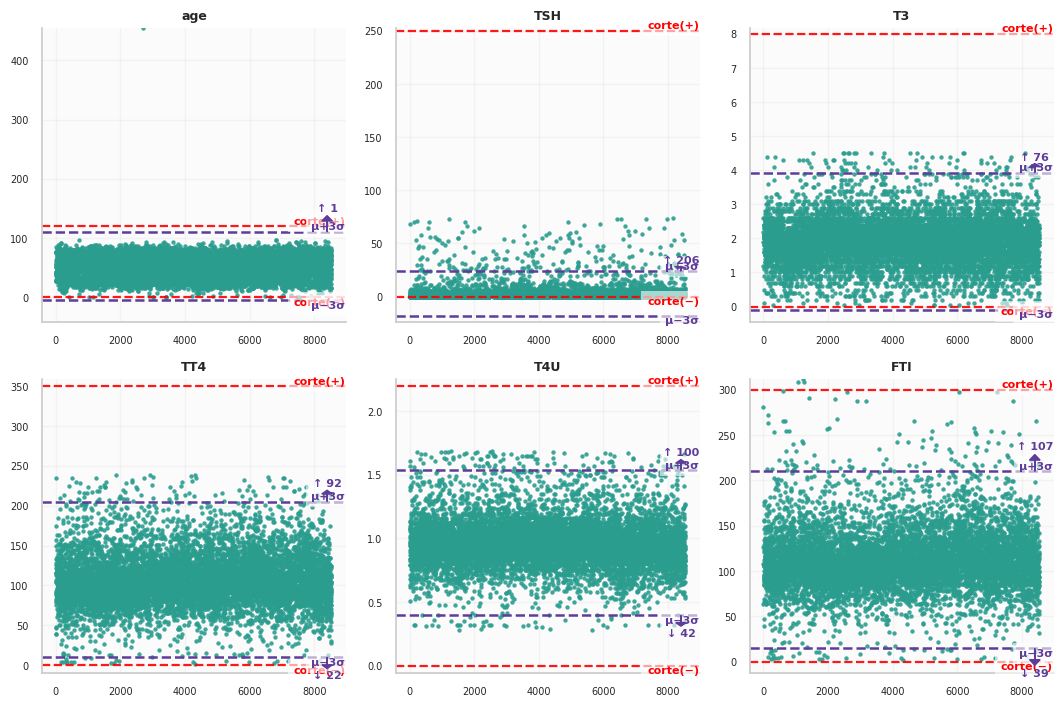

CSV de outliers (|z|>=3) salvo em: ../eda_reports/csv/outliers_3sigma.csv (linhas: 511)
Linhas removidas do df por regra |z|>=3: 511 (antes=8536, depois=8025)


In [ ]:
# [3DP - Executar essa ou a 3DP - NÃO RODAR AS DUAS] Scatter simples por variável numérica com regra fixa de 3σ, layout 3 colunas, cores e linhas mais visíveis
# Ao final: salvar CSV com outliers (|z| >= 3, i.e., <= média - 3*desvio OU >= média + 3*desvio) para age, TSH, T3, TT4, T4U, FTI
# e atualizar df removendo essas linhas. CSV inclui colunas de flags por variável, out_any e trigger_cols.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import unicodedata

sns.set_theme(style='whitegrid')

# Colunas a excluir explicitamente dos plots
EXCLUDE_EXPLICIT = {'patient_id', 'Patient_ID', 'ID', 'Id', 'y', 'Y'}

# Helpers de normalização e detecção
_norm_cache = {}

def _normalize_name(name: str) -> str:
    if name in _norm_cache:
        return _norm_cache[name]
    s = unicodedata.normalize('NFKD', str(name))
    s = s.encode('ascii', 'ignore').decode('ascii')
    s = s.lower()
    s = re.sub(r'\(.*?\)', '', s)
    s = re.sub(r'[^a-z0-9]+', '', s)
    _norm_cache[name] = s
    return s

def _is_age(name: str) -> bool:
    n = _normalize_name(name)
    return ('age' in n) or ('idade' in n)

def _is_tsh(name: str) -> bool:
    return 'tsh' in _normalize_name(name)

def _is_t3(name: str) -> bool:
    return 't3' in _normalize_name(name)

def _is_t4u(name: str) -> bool:
    return 't4u' in _normalize_name(name)

def _is_tt4(name: str) -> bool:
    n = _normalize_name(name)
    return ('tt4' in n) or (('t4' in n) and ('t4u' not in n) and ('ft' not in n) and ('free' not in n))

def _is_fti(name: str) -> bool:
    return 'fti' in _normalize_name(name)

# Selecionar apenas variáveis numéricas (com coerção quando necessário)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) == 0:
    cand = {}
    for c in df.columns:
        coer = pd.to_numeric(df[c], errors='coerce')
        if coer.notna().mean() >= 0.5:
            cand[c] = coer
    df_num = pd.DataFrame(cand)
    num_cols = df_num.columns.tolist()
else:
    df_num = df[num_cols].apply(lambda s: pd.to_numeric(s, errors='coerce'))

# Excluir IDs/targets conhecidos
num_cols = [c for c in num_cols if c not in EXCLUDE_EXPLICIT]

# Construir mapeamento das colunas-alvo (para CSV e limpeza): age, TSH, T3, TT4, T4U, FTI
# Heurística original (mantida para compatibilidade)
target_keys = {
    'age': None,
    'TSH': None,
    'T3': None,
    'TT4': None,
    'T4U': None,
    'FTI': None,
}
MANUAL_CUTOFFS = {
    "TSH": (0, 250),       # (corte_min, corte_max)
    "T3":  (0, 8.0),
    "TT4": (0, 350),
    "T4U": (0, 2.2),
    "FTI": (0, 300),
    "age": (0, 120)
}
for c in df.columns:
    if target_keys['age'] is None and _is_age(c):
        target_keys['age'] = c
    if target_keys['TSH'] is None and _is_tsh(c):
        target_keys['TSH'] = c
    if target_keys['T3'] is None and _is_t3(c):
        target_keys['T3'] = c
    if target_keys['TT4'] is None and _is_tt4(c):
        target_keys['TT4'] = c
    if target_keys['T4U'] is None and _is_t4u(c):
        target_keys['T4U'] = c
    if target_keys['FTI'] is None and _is_fti(c):
        target_keys['FTI'] = c

# Override: usar exatamente os nomes informados pelo usuário, não remover colunas, apenas linhas
_exact_cols = ['age', 'T4U', 'FTI', 'TSH', 'T3', 'TT4']
# Considerar apenas as que existem no df
_exact_present = [c for c in _exact_cols if c in df.columns]
# Remontar o dicionário target_keys preservando as chaves esperadas
_target_override = {k: (k if k in _exact_present else None) for k in ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']}
# Substituir o mapeamento
target_keys = _target_override

# ========= PLOTS: 3 colunas, subplots quadrados, 3σ somente =========
if len(num_cols) > 0:
    cols = 3
    rows = (len(num_cols) + cols - 1) // cols

    side = 3.6
    fig_width = max(7.5, side * cols)
    fig_height = max(3.2, side * rows)

    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height), constrained_layout=False)
    fig.patch.set_facecolor('white')
    axes = np.atleast_1d(axes).flatten()

    point_color = '#2a9d8f'   # teal, mais agradável
    sigma_color = '#5e3c99'   # roxo escuro, linhas visíveis
    cutoff_color = 'red'      # NOVO: cor da linha de corte (pontilhada vermelha)

    for i, c in enumerate(num_cols):
        ax = axes[i]
        ax.set_facecolor('#fbfbfb')
        s = pd.to_numeric(df_num[c], errors='coerce')
        idx = np.arange(len(s))

        # Scatter simples em escala linear
        ax.scatter(idx, s, s=10, c=point_color, alpha=0.9, linewidths=0)

        s_non = s.dropna()
        if len(s_non) >= 2:
            mu = float(np.nanmean(s_non))
            sd = float(np.nanstd(s_non, ddof=1)) if len(s_non) > 1 else float(np.nanstd(s_non))
            low3 = mu - 3 * sd
            high3 = mu + 3 * sd

            # Linhas exatamente em μ±3σ
            ax.axhline(low3, color=sigma_color, linestyle='--', linewidth=1.8, alpha=1.0, zorder=2)
            ax.axhline(high3, color=sigma_color, linestyle='--', linewidth=1.8, alpha=1.0, zorder=2)

            # Contagens de pontos abaixo/acima (|z|>=3)
            n_below = int((s <= low3).sum())
            n_above = int((s >= high3).sum())

            # Ajuste de limites para não cortar setas/texto
            y_min_data = float(np.nanmin(s_non))
            y_max_data = float(np.nanmax(s_non))
            y_rng = max(1e-9, y_max_data - y_min_data)
            y_low_plot = min(y_min_data, low3 - 0.08 * y_rng)
            y_high_plot = max(y_max_data, high3 + 0.08 * y_rng)

            # === NOVO: linhas de corte manuais (μ_corte− / μ_corte+) ===
            # Espera-se um dicionário MANUAL_CUTOFFS = {col: (low_cut, high_cut), ...}
            manual_low = manual_high = None
            if 'MANUAL_CUTOFFS' in globals() and c in MANUAL_CUTOFFS:
                manual_low, manual_high = MANUAL_CUTOFFS[c]

                # linhas pontilhadas vermelhas
                ax.axhline(manual_low,  color=cutoff_color, linestyle='--', linewidth=1.6, alpha=0.9, zorder=2.5)
                ax.axhline(manual_high, color=cutoff_color, linestyle='--', linewidth=1.6, alpha=0.9, zorder=2.5)

                # rótulos das linhas de corte
                x0, x1 = ax.get_xlim()
                ax.text(x1, manual_high, 'corte(+)', fontsize=8, color=cutoff_color, weight='bold',
                        va='bottom', ha='right',
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))
                ax.text(x1, manual_low, 'corte(−)', fontsize=8, color=cutoff_color, weight='bold',
                        va='top', ha='right',
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))

                # incluir cortes no cálculo de limites do eixo
                y_low_plot = min(y_low_plot, manual_low  - 0.04 * y_rng)
                y_high_plot = max(y_high_plot, manual_high + 0.04 * y_rng)

            ax.set_ylim(y_low_plot, y_high_plot)

            # Rótulos das linhas (μ±3σ)
            x0, x1 = ax.get_xlim()
            ax.text(x1, high3, 'μ+3σ', fontsize=8, color=sigma_color, weight='bold',
                    va='bottom', ha='right', bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))
            ax.text(x1, low3, 'μ−3σ', fontsize=8, color=sigma_color, weight='bold',
                    va='top', ha='right', bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))

            # Setas e contagens
            x_arrow = x1 - 0.06 * (x1 - x0)
            if n_above > 0:
                dy = 0.06 * y_rng
                ax.arrow(x_arrow, high3, 0, dy, length_includes_head=True,
                         head_width=0.035 * (x1 - x0), head_length=0.02 * y_rng,
                         fc=sigma_color, ec=sigma_color, linewidth=1.0, zorder=3)
                ax.text(x_arrow, high3 + dy + 0.01 * y_rng, f"↑ {n_above}",
                        fontsize=8, color=sigma_color, weight='bold', va='bottom', ha='center')
            if n_below > 0:
                dy = -0.06 * y_rng
                ax.arrow(x_arrow, low3, 0, dy, length_includes_head=True,
                         head_width=0.035 * (x1 - x0), head_length=0.02 * y_rng,
                         fc=sigma_color, ec=sigma_color, linewidth=1.0, zorder=3)
                ax.text(x_arrow, low3 + dy - 0.01 * y_rng, f"↓ {n_below}",
                        fontsize=8, color=sigma_color, weight='bold', va='top', ha='center')

        # Título pequeno
        ax.set_title(str(c), fontsize=9, fontweight='bold', pad=6)

        # Eixos legíveis e limpos
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(axis='both', which='major', linestyle='-', alpha=0.18)
        ax.grid(axis='both', which='minor', linestyle='-', alpha=0.08)
        sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)

    # Remover eixos extras
    last_i = i if len(num_cols) > 0 else -1
    for j in range(last_i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(pad=1.0, w_pad=0.9, h_pad=0.9)

    # Salvar figura
    try:
        try:
            IMAGES
        except NameError:
            IMAGES = os.path.join(BASE, 'eda_reports', 'images') if 'BASE' in globals() else os.path.join('databases','UCI-THYROID-DXBIN','eda_reports','images')
        os.makedirs(IMAGES, exist_ok=True)
        dpi = OUTPUT_DPI if 'OUTPUT_DPI' in globals() else 300
        out_path = os.path.join(IMAGES, 'outliers_scatter.png')
        plt.savefig(out_path, dpi=dpi, bbox_inches='tight')
        print(f'Figura salva em: {out_path}')
    except Exception as e:
        print('Falha ao salvar figura:', e)

    plt.show()
else:
    print('Nenhuma variável numérica disponível para plot.')

# ========= CSV de outliers (|z| >= 3) e atualização do df =========
# Calcular máscaras de outliers para as colunas-alvo existentes
outlier_flags = {}
combined_mask = pd.Series(False, index=df.index)

for key, col in target_keys.items():
    if col is None or col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors='coerce')
    s_non = s.dropna()
    if len(s_non) < 2:
        outlier_flags[key] = pd.Series(False, index=df.index)
        continue
    mu = float(np.nanmean(s_non))
    sd = float(np.nanstd(s_non, ddof=1)) if len(s_non) > 1 else float(np.nanstd(s_non))
    thr_low = mu - 3 * sd
    thr_high = mu + 3 * sd
    mask = (s <= thr_low) | (s >= thr_high)
    mask = mask.fillna(False)
    outlier_flags[key] = mask
    combined_mask = combined_mask | mask

# Montar DataFrame de flags alinhado ao df
flag_cols = {}
for key, mask in outlier_flags.items():
    if key in target_keys and target_keys[key] is not None:
        flag_cols[f'out_{key.lower()}'] = mask.astype(int)
flags_df = pd.DataFrame(flag_cols, index=df.index)
if not flags_df.empty:
    flags_df['out_any'] = (flags_df.sum(axis=1) > 0).astype(int)
    # Lista de colunas que dispararam por linha
    def _join_triggers(row):
        cols = [k.replace('out_', '') for k, v in row.items() if k.startswith('out_') and v == 1]
        return ','.join(cols)
    flags_df['trigger_cols'] = flags_df.apply(_join_triggers, axis=1)
else:
    # Garantir as colunas mesmo se vazias
    flags_df['out_any'] = 0
    flags_df['trigger_cols'] = ''

# Filtrar linhas outliers e salvar CSV (antes de remover do df)
if combined_mask.any():
    out_df = df.loc[combined_mask].copy()
    out_df = out_df.join(flags_df.loc[out_df.index])
    try:
        try:
            CSV_DIR
        except NameError:
            CSV_DIR = os.path.join(BASE, 'eda_reports', 'csv') if 'BASE' in globals() else os.path.join('databases','UCI-THYROID-DXBIN','eda_reports','csv')
        os.makedirs(CSV_DIR, exist_ok=True)
        csv_path = os.path.join(CSV_DIR, 'outliers_3sigma.csv')
        out_df.to_csv(csv_path, index=True)
        print(f'CSV de outliers (|z|>=3) salvo em: {csv_path} (linhas: {len(out_df)})')
    except Exception as e:
        print('Falha ao salvar CSV de outliers:', e)
else:
    print('Nenhum outlier (|z|>=3) encontrado nas colunas-alvo.')

# Atualizar df removendo as linhas outliers (ambos os lados)
if combined_mask.any():
    before = len(df)
    df = df.loc[~combined_mask].copy()
    after = len(df)
    removed = before - after
    print(f'Linhas removidas do df por regra |z|>=3: {removed} (antes={before}, depois={after})')
else:
    print('df não alterado: nenhuma linha removida pela regra |z|>=3.')

In [ ]:
#####################################################################################

In [ ]:
# [IQR - Executar essa ou a 3DP - NÃO RODAR AS DUAS] Scatter simples por variável numérica com regra de Tukey (1.5*IQR), layout 3 colunas, cores e linhas mais visíveis
# Ao final: salvar CSV com outliers (x < Q1 - 1.5*IQR OU x > Q3 + 1.5*IQR) para age, TSH, T3, TT4, T4U, FTI
# e atualizar df removendo essas linhas. CSV inclui colunas de flags por variável, out_any e trigger_cols.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import unicodedata

sns.set_theme(style='whitegrid')

# Colunas a excluir explicitamente dos plots
EXCLUDE_EXPLICIT = {'patient_id', 'Patient_ID', 'ID', 'Id', 'y', 'Y'}

# Helpers de normalização e detecção
_norm_cache = {}

def _normalize_name(name: str) -> str:
    if name in _norm_cache:
        return _norm_cache[name]
    s = unicodedata.normalize('NFKD', str(name))
    s = s.encode('ascii', 'ignore').decode('ascii')
    s = s.lower()
    s = re.sub(r'\(.*?\)', '', s)
    s = re.sub(r'[^a-z0-9]+', '', s)
    _norm_cache[name] = s
    return s

def _is_age(name: str) -> bool:
    n = _normalize_name(name)
    return ('age' in n) or ('idade' in n)

def _is_tsh(name: str) -> bool:
    return 'tsh' in _normalize_name(name)

def _is_t3(name: str) -> bool:
    return 't3' in _normalize_name(name)

def _is_t4u(name: str) -> bool:
    return 't4u' in _normalize_name(name)

def _is_tt4(name: str) -> bool:
    n = _normalize_name(name)
    return ('tt4' in n) or (('t4' in n) and ('t4u' not in n) and ('ft' not in n) and ('free' not in n))

def _is_fti(name: str) -> bool:
    return 'fti' in _normalize_name(name)

# Selecionar apenas variáveis numéricas (com coerção quando necessário)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) == 0:
    cand = {}
    for c in df.columns:
        coer = pd.to_numeric(df[c], errors='coerce')
        if coer.notna().mean() >= 0.5:
            cand[c] = coer
    df_num = pd.DataFrame(cand)
    num_cols = df_num.columns.tolist()
else:
    df_num = df[num_cols].apply(lambda s: pd.to_numeric(s, errors='coerce'))

# Excluir IDs/targets conhecidos
num_cols = [c for c in num_cols if c not in EXCLUDE_EXPLICIT]

# Construir mapeamento das colunas-alvo (para CSV e limpeza): age, TSH, T3, TT4, T4U, FTI
# Heurística original (mantida para compatibilidade)
target_keys = {
    'age': None,
    'TSH': None,
    'T3': None,
    'TT4': None,
    'T4U': None,
    'FTI': None,
}
for c in df.columns:
    if target_keys['age'] is None and _is_age(c):
        target_keys['age'] = c
    if target_keys['TSH'] is None and _is_tsh(c):
        target_keys['TSH'] = c
    if target_keys['T3'] is None and _is_t3(c):
        target_keys['T3'] = c
    if target_keys['TT4'] is None and _is_tt4(c):
        target_keys['TT4'] = c
    if target_keys['T4U'] is None and _is_t4u(c):
        target_keys['T4U'] = c
    if target_keys['FTI'] is None and _is_fti(c):
        target_keys['FTI'] = c

# Override: usar exatamente os nomes informados pelo usuário, não remover colunas, apenas linhas
_exact_cols = ['age', 'T4U', 'FTI', 'TSH', 'T3', 'TT4']
# Considerar apenas as que existem no df
_exact_present = [c for c in _exact_cols if c in df.columns]
# Remontar o dicionário target_keys preservando as chaves esperadas
_target_override = {k: (k if k in _exact_present else None) for k in ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']}
# Substituir o mapeamento
target_keys = _target_override

# ========= PLOTS: 3 colunas, subplots quadrados, Tukey 1.5*IQR =========
if len(num_cols) > 0:
    cols = 3
    rows = (len(num_cols) + cols - 1) // cols

    side = 3.6
    fig_width = max(7.5, side * cols)
    fig_height = max(3.2, side * rows)

    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height), constrained_layout=False)
    fig.patch.set_facecolor('white')
    axes = np.atleast_1d(axes).flatten()

    point_color = '#2a9d8f'   # teal, mais agradável
    tukey_color = '#5e3c99'   # roxo escuro, linhas visíveis

    for i, c in enumerate(num_cols):
        ax = axes[i]
        ax.set_facecolor('#fbfbfb')
        s = pd.to_numeric(df_num[c], errors='coerce')
        idx = np.arange(len(s))

        # Scatter simples em escala linear
        ax.scatter(idx, s, s=10, c=point_color, alpha=0.9, linewidths=0)

        s_non = s.dropna()
        if len(s_non) >= 2:
            q1 = float(np.nanpercentile(s_non, 25))
            q3 = float(np.nanpercentile(s_non, 75))
            iqr = q3 - q1
            low_t = q1 - 1.5 * iqr
            high_t = q3 + 1.5 * iqr

            # Linhas em Q1-1.5*IQR e Q3+1.5*IQR
            ax.axhline(low_t, color=tukey_color, linestyle='--', linewidth=1.8, alpha=1.0, zorder=2)
            ax.axhline(high_t, color=tukey_color, linestyle='--', linewidth=1.8, alpha=1.0, zorder=2)

            # Contagens de pontos abaixo/acima (Tukey 1.5*IQR)
            n_below = int((s <= low_t).sum())
            n_above = int((s >= high_t).sum())

            # Ajuste de limites para não cortar setas/texto
            y_min_data = float(np.nanmin(s_non))
            y_max_data = float(np.nanmax(s_non))
            y_rng = max(1e-9, y_max_data - y_min_data)
            y_low_plot = min(y_min_data, low_t - 0.08 * y_rng)
            y_high_plot = max(y_max_data, high_t + 0.08 * y_rng)
            ax.set_ylim(y_low_plot, y_high_plot)

            # Rótulos das linhas
            x0, x1 = ax.get_xlim()
            ax.text(x1, high_t, 'Q3+1.5×IQR', fontsize=8, color=tukey_color, weight='bold',
                    va='bottom', ha='right', bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))
            ax.text(x1, low_t, 'Q1−1.5×IQR', fontsize=8, color=tukey_color, weight='bold',
                    va='top', ha='right', bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))

            # Setas e contagens
            x_arrow = x1 - 0.06 * (x1 - x0)
            if n_above > 0:
                dy = 0.06 * y_rng
                ax.arrow(x_arrow, high_t, 0, dy, length_includes_head=True,
                         head_width=0.035 * (x1 - x0), head_length=0.02 * y_rng,
                         fc=tukey_color, ec=tukey_color, linewidth=1.0, zorder=3)
                ax.text(x_arrow, high_t + dy + 0.01 * y_rng, f"↑ {n_above}",
                        fontsize=8, color=tukey_color, weight='bold', va='bottom', ha='center')
            if n_below > 0:
                dy = -0.06 * y_rng
                ax.arrow(x_arrow, low_t, 0, dy, length_includes_head=True,
                         head_width=0.035 * (x1 - x0), head_length=0.02 * y_rng,
                         fc=tukey_color, ec=tukey_color, linewidth=1.0, zorder=3)
                ax.text(x_arrow, low_t + dy - 0.01 * y_rng, f"↓ {n_below}",
                        fontsize=8, color=tukey_color, weight='bold', va='top', ha='center')

        # Título pequeno
        ax.set_title(str(c), fontsize=9, fontweight='bold', pad=6)

        # Eixos legíveis e limpos
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(axis='both', which='major', linestyle='-', alpha=0.18)
        ax.grid(axis='both', which='minor', linestyle='-', alpha=0.08)
        sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)

    # Remover eixos extras
    last_i = i if len(num_cols) > 0 else -1
    for j in range(last_i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(pad=1.0, w_pad=0.9, h_pad=0.9)

    # Salvar figura
    try:
        try:
            IMAGES
        except NameError:
            IMAGES = os.path.join(BASE, 'eda_reports', 'images') if 'BASE' in globals() else os.path.join('databases','UCI-THYROID-DXBIN','eda_reports','images')
        os.makedirs(IMAGES, exist_ok=True)
        dpi = OUTPUT_DPI if 'OUTPUT_DPI' in globals() else 300
        out_path = os.path.join(IMAGES, 'outliers_scatter_iqr.png')
        plt.savefig(out_path, dpi=dpi, bbox_inches='tight')
        print(f'Figura salva em: {out_path}')
    except Exception as e:
        print('Falha ao salvar figura:', e)

    plt.show()
else:
    print('Nenhuma variável numérica disponível para plot.')

# ========= CSV de outliers (Tukey 1.5*IQR) e atualização do df =========
# Calcular máscaras de outliers para as colunas-alvo existentes
outlier_flags = {}
combined_mask = pd.Series(False, index=df.index)

for key, col in target_keys.items():
    if col is None or col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors='coerce')
    s_non = s.dropna()
    if len(s_non) < 2:
        outlier_flags[key] = pd.Series(False, index=df.index)
        continue
    q1 = float(np.nanpercentile(s_non, 25))
    q3 = float(np.nanpercentile(s_non, 75))
    iqr = q3 - q1
    thr_low = q1 - 1.5 * iqr
    thr_high = q3 + 1.5 * iqr
    mask = (s <= thr_low) | (s >= thr_high)
    mask = mask.fillna(False)
    outlier_flags[key] = mask
    combined_mask = combined_mask | mask

# Montar DataFrame de flags alinhado ao df
flag_cols = {}
for key, mask in outlier_flags.items():
    if key in target_keys and target_keys[key] is not None:
        flag_cols[f'out_{key.lower()}'] = mask.astype(int)
flags_df = pd.DataFrame(flag_cols, index=df.index)
if not flags_df.empty:
    flags_df['out_any'] = (flags_df.sum(axis=1) > 0).astype(int)
    # Lista de colunas que dispararam por linha
    def _join_triggers(row):
        cols = [k.replace('out_', '') for k, v in row.items() if k.startswith('out_') and v == 1]
        return ','.join(cols)
    flags_df['trigger_cols'] = flags_df.apply(_join_triggers, axis=1)
else:
    # Garantir as colunas mesmo se vazias
    flags_df['out_any'] = 0
    flags_df['trigger_cols'] = ''

# Filtrar linhas outliers e salvar CSV (antes de remover do df)
if combined_mask.any():
    out_df = df.loc[combined_mask].copy()
    out_df = out_df.join(flags_df.loc[out_df.index])
    try:
        try:
            CSV_DIR
        except NameError:
            CSV_DIR = os.path.join(BASE, 'eda_reports', 'csv') if 'BASE' in globals() else os.path.join('databases','UCI-THYROID-DXBIN','eda_reports','csv')
        os.makedirs(CSV_DIR, exist_ok=True)
        csv_path = os.path.join(CSV_DIR, 'outliers_iqr.csv')
        out_df.to_csv(csv_path, index=True)
        print(f'CSV de outliers (Tukey 1.5*IQR) salvo em: {csv_path} (linhas: {len(out_df)})')
    except Exception as e:
        print('Falha ao salvar CSV de outliers:', e)
else:
    print('Nenhum outlier (Tukey 1.5*IQR) encontrado nas colunas-alvo.')

# Atualizar df removendo as linhas outliers (ambos os lados)
if combined_mask.any():
    before = len(df)
    df = df.loc[~combined_mask].copy()
    after = len(df)
    removed = before - after
    print(f'Linhas removidas do df por regra Tukey 1.5*IQR: {removed} (antes={before}, depois={after})')
else:
    print('df não alterado: nenhuma linha removida pela regra Tukey 1.5*IQR.')

/tmp/ipykernel_7026/2513881102.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s, order=present, ax=ax, palette=palette)
/tmp/ipykernel_7026/2513881102.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s, order=present, ax=ax, palette=palette)
/tmp/ipykernel_7026/2513881102.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s, order=present, ax=ax, palette=palette)
/tmp/ipykernel_7026/2513881102.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x`

Figura salva em: ../eda_reports/images/balance_binary.png


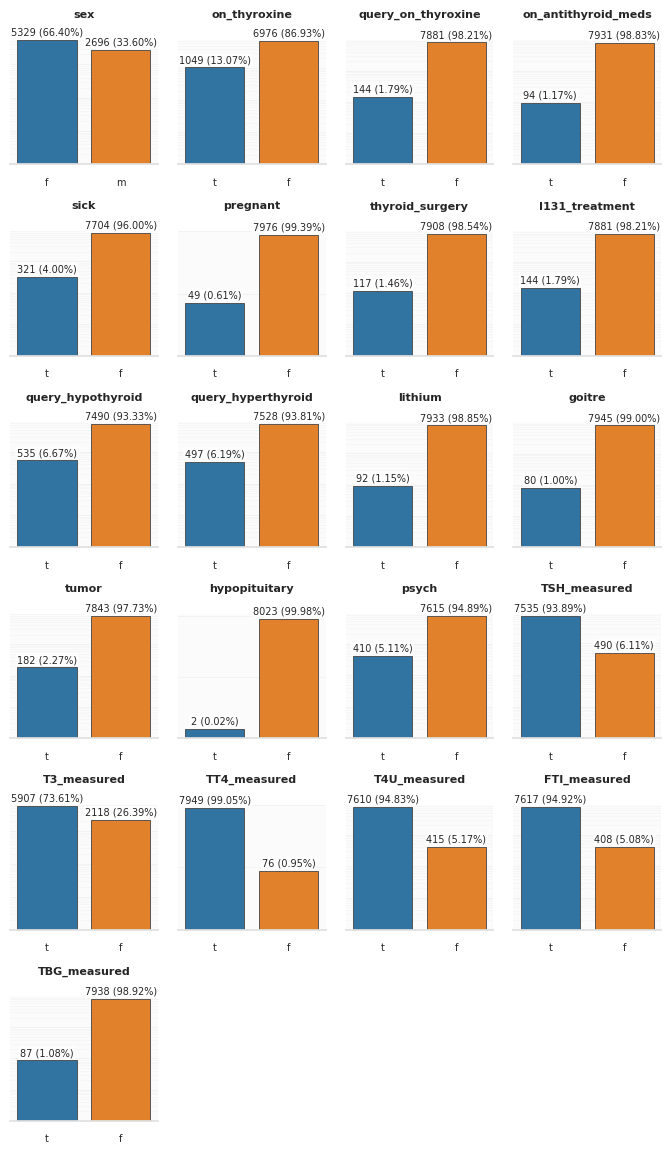

In [39]:
# Balanceamento da variaveis categorias - binárias (t/f)
# Estética melhorada: tema limpo, títulos enxutos, barras com borda, anotações legíveis
# Orientação vertical (A4 portrait mais estreita), y em log10, cores azul/laranja
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import textwrap

# Estilo global mais limpo
sns.set_theme(style='whitegrid', rc={
    'axes.edgecolor': '#E0E0E0',
    'grid.color': '#DADADA',
    'grid.linewidth': 0.6,
    'axes.labelsize': 8,
    'font.size': 8
})

# Helper para normalizar e ignorar NaNs reais e strings 'nan'
def normalize_binary_series(series):
    s = series.copy()
    s = s.astype(str).str.strip().str.lower()
    s = s.replace({'true': 't', 'false': 'f'})
    s = s.replace({'nan': np.nan, 'none': np.nan, '': np.nan})
    return s

# Descobrir colunas categóricas binárias (2 categorias válidas após normalização t/f)
binary_cols = []
cat_cols = [c for c in df.columns if c not in num_cols]
for c in cat_cols:
    try:
        s_norm = normalize_binary_series(df[c])
        nunq = s_norm.dropna().nunique()
        if nunq == 2:
            binary_cols.append(c)
    except Exception:
        continue

num_binary = len(binary_cols)

if num_binary > 0:
    cols = 4
    rows = (num_binary + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7.0, 11.7), constrained_layout=False)
    fig.patch.set_facecolor('white')
    axes = np.atleast_1d(axes).flatten()

    palette = ['#1f77b4', '#ff7f0e']  # azul/laranja

    for i, c in enumerate(binary_cols):
        ax = axes[i]
        ax.set_facecolor('#fbfbfb')
        s = normalize_binary_series(df[c])
        order_pref = ['t', 'f']
        present = [x for x in order_pref if x in s.dropna().unique()]
        if len(present) < 2:
            present = sorted([v for v in s.dropna().unique()])[:2]
        sns.countplot(x=s, order=present, ax=ax, palette=palette)

        # Título: apenas nome da variável, negrito, fonte 8, texto quebrado se muito longo
        title = textwrap.fill(str(c), width=30)
        ax.set_title(title, fontsize=8, fontweight='bold', pad=16)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='y', which='both', labelleft=False)
        ax.tick_params(axis='x', labelsize=7)

        # Escala log10 no eixo Y
        ax.set_yscale('log')
        denom = s.notna().sum()

        # Estética das barras + anotações
        for p in ax.patches:
            try:
                p.set_linewidth(0.6)
                p.set_edgecolor('#444444')
            except Exception:
                pass
            height = p.get_height()
            if height and height > 0 and denom > 0:
                pct = height / denom * 100.0
                ax.annotate(f'{int(height)} ({pct:.2f}%)',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=7,
                            xytext=(0, 2), textcoords='offset points',
                            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))

        # Grade sutil e spines mínimos
        ax.grid(axis='y', which='major', linestyle='-', alpha=0.3)
        ax.grid(axis='y', which='minor', linestyle='-', alpha=0.15)
        ax.set_ylim(bottom=1)
        sns.despine(ax=ax, left=True, right=True, top=True, bottom=False)

    # Remover eixos extras
    last_i = i if num_binary > 0 else -1
    for j in range(last_i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Ajustes de layout
    plt.tight_layout(pad=1.6, w_pad=0.6, h_pad=1.2)

    # Salvar figura
    try:
        try:
            IMAGES
        except NameError:
            IMAGES = os.path.join(BASE, 'eda_reports', 'images') if 'BASE' in globals() else os.path.join('databases','UCI-THYROID-DXBIN','eda_reports','images')
        os.makedirs(IMAGES, exist_ok=True)
        dpi = OUTPUT_DPI if 'OUTPUT_DPI' in globals() else 300
        out_path = os.path.join(IMAGES, 'balance_binary.png')
        plt.savefig(out_path, dpi=dpi, bbox_inches='tight')
        print(f'Figura salva em: {out_path}')
    except Exception as e:
        print('Falha ao salvar figura de balanceamento binário:', e)

    plt.show()
else:
    print('Nenhuma variável categórica binária encontrada para balanceamento.')

In [40]:
df

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,referral_source,target,patient_id,target_,y
1,29,F,F,F,F,F,F,F,F,F,...,F,0.96,F,126.0,F,other,-,840801014,Negative,0
6,77,F,F,F,F,F,F,F,F,F,...,F,0.71,F,108.0,T,other,-,840803068,Negative,0
7,28,F,F,F,F,F,F,F,F,F,...,F,0.98,F,156.0,F,SVI,-,840807019,Negative,0
8,28,F,F,F,F,F,F,F,F,F,...,F,0.79,F,90.0,F,other,-,840808060,Negative,0
9,28,F,F,F,F,F,F,F,F,F,...,F,0.82,F,86.0,F,other,-,840808073,Negative,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9157,56,M,F,F,F,F,F,F,F,F,...,T,0.83,T,77.0,F,SVI,-,870119022,Negative,0
9158,22,M,F,F,F,F,F,F,F,F,...,T,0.92,T,99.0,F,SVI,-,870119023,Negative,0
9159,69,M,F,F,F,F,F,F,F,F,...,T,1.27,T,89.0,F,SVI,I,870119025,Hyperthyroid,2
9160,47,F,F,F,F,F,F,F,F,F,...,T,0.85,T,88.0,F,other,-,870119027,Negative,0


In [41]:
# Salva versão 'processed' simples para consumo posterior (parquet se possível)
processed_dir = os.path.join('..','data','processed')
os.makedirs(processed_dir, exist_ok=True)
proc_csv = os.path.join(processed_dir, 'uci_thyroid_dxbin_processed.csv')
df.to_csv(proc_csv, index=False)
print('Saved processed CSV:', proc_csv)


Saved processed CSV: ../data/processed/uci_thyroid_dxbin_processed.csv


In [42]:
def save_fig(fig, name, dpi=None):
    if dpi is None:
        dpi = OUTPUT_DPI
    path = os.path.join(IMAGES, name)
    fig.savefig(path, bbox_inches='tight', dpi=dpi)
    print(f'Saved {path} (dpi={dpi})')
    return path

# Histogramas em grid - somente colunas numéricas (robusto)
n = len(num_cols)
if n == 0:
    print('Nenhuma coluna numérica detectada - pulando histogramas e boxplots')
else:
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*3.5), constrained_layout=False)
    axes = np.array(axes).flatten()
    last_i = -1
    for i, c in enumerate(num_cols):
        ax = axes[i]
        ser = pd.to_numeric(df[c], errors='coerce').dropna()
        if ser.empty:
            ax.axis('off')
            ax.text(0.5, 0.5, 'no non-NA numeric values', ha='center', va='center')
            ax.set_title(c, fontsize=10)
            last_i = i
            continue
        sns.histplot(ser, ax=ax, kde=True, color='C0')
        ax.set_title(c, fontsize=10)
        last_i = i
    # limpa e esconde eixos extras
    for j in range(last_i+1, len(axes)):
        try:
            axes[j].axis('off')
        except Exception:
            pass
    fig.subplots_adjust(hspace=0.5, wspace=0.4)
    save_fig(fig, 'histograms_grid.png')
    plt.close(fig)

    # Boxplots em grid (robusto) - evita chamar seaborn com dados inválidos
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*3.5), constrained_layout=False)
    axes = np.array(axes).flatten()
    last_i = -1
    for i, c in enumerate(num_cols):
        ax = axes[i]
        ser = pd.to_numeric(df[c], errors='coerce').dropna()
        if ser.empty or ser.nunique() <= 1:
            ax.axis('off')
            ax.text(0.5, 0.5, 'no data or constant', ha='center', va='center')
            ax.set_title(c, fontsize=10)
            last_i = i
            continue
        try:
            sns.boxplot(x=ser, ax=ax, color='C1')
        except Exception:
            ax.axis('off')
            ax.text(0.5, 0.5, 'plot error', ha='center', va='center')
        ax.set_title(c, fontsize=10)
        last_i = i
    for j in range(last_i+1, len(axes)):
        try:
            axes[j].axis('off')
        except Exception:
            pass
    fig.subplots_adjust(hspace=0.6, wspace=0.4)
    save_fig(fig, 'boxplots_grid.png')
    plt.close(fig)

Saved ../eda_reports/images/histograms_grid.png (dpi=800)
Saved ../eda_reports/images/boxplots_grid.png (dpi=800)


In [43]:
# Correlação de Pearson e heatmap anotado apenas para |r| > 0.3 (landscape / horizontal page)
corr = df[num_cols].corr(method='pearson')
mask = corr.abs() < 0.3
# Preparar anotações: somente onde |r| >= 0.3
annot = corr.round(2).astype(str)
annot = annot.where(~mask, '')
# Use a wider figure for horizontal/landscape layout
fig_w = max(11, len(num_cols) * 0.35)
fig_h = max(6, len(num_cols) * 0.2)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    corr,
    mask=None,
    cmap='coolwarm',
    center=0,
    ax=ax,
    annot=annot,
    fmt='',
    annot_kws={'size':5, 'weight':'bold'},
    linewidths=0.2,
    square=False,
    cbar_kws={'shrink':1.0}
)
# reduce tick label sizes
ax.tick_params(axis='both', which='major', labelsize=7)
ax.set_title('Pearson Correlation (only |r| >= 0.3 annotated)', fontsize=12)
plt.tight_layout()
# save as a landscape PNG using OUTPUT_DPI
save_fig(fig, 'correlation_heatmap.png', dpi=OUTPUT_DPI)
plt.close(fig)


Saved ../eda_reports/images/correlation_heatmap.png (dpi=800)


In [45]:
# Normality tests (Shapiro / D'Agostino) for top skewed numeric variables - Q-Q plots removed as requested
from scipy.stats import shapiro, normaltest
# Compute skewness and pick top skewed numeric columns (stable against non-numeric)
skew_vals = df[num_cols].apply(lambda x: pd.to_numeric(x, errors='coerce').dropna().skew())
skewed = skew_vals.abs().sort_values(ascending=False).head(6).index.tolist()
print('Top skewed cols (for tests):', skewed)
results = []
for c in skewed:
    # Coerce to numeric and drop NA
    series = pd.to_numeric(df[c], errors='coerce').dropna()
    n = len(series)
    info = {'variable': c, 'n': n, 'shapiro_stat': None, 'shapiro_p': None, 'dagostino_stat': None, 'dagostino_p': None, 'notes': ''}
    if n == 0:
        info['notes'] = 'no_non_na_values'
        results.append(info)
        continue
    # skip constant columns (variance==0) which break tests
    if series.nunique() <= 1 or series.std() == 0 or series.var() == 0:
        info['notes'] = 'constant_or_zero_variance'
        results.append(info)
        continue
    # sample for large n to keep Shapiro runtime reasonable
    sample = series.sample(n=min(n, 5000), random_state=0) if n > 5000 else series
    # Shapiro: recommended for n <= 5000; wrap in try/except
    try:
        s_stat, s_p = shapiro(sample)
        info['shapiro_stat'] = float(s_stat) if s_stat is not None else None
        info['shapiro_p'] = float(s_p) if s_p is not None else None
    except Exception as e:
        info['notes'] += ' shapiro_failed:' + str(e)
    # D'Agostino (normaltest) requires at least 8 samples
    try:
        if len(sample) >= 8:
            n_stat, n_p = normaltest(sample)
            info['dagostino_stat'] = float(n_stat)
            info['dagostino_p'] = float(n_p)
        else:
            info['notes'] += ' dagostino_skipped_small_n'
    except Exception as e:
        info['notes'] += ' dagostino_failed:' + str(e)
    results.append(info)
# Results dataframe with richer diagnostics
results_df = pd.DataFrame(results).set_index('variable')
display(results_df)
results_df.to_csv(os.path.join(CSV_DIR, 'normality_tests.csv'))

Top skewed cols (for tests): ['TSH', 'FTI', 'TT4', 'T4U', 'age', 'T3']


,n,shapiro_stat,shapiro_p,dagostino_stat,dagostino_p,notes
variable,,,,,,
TSH,8025,0.630390,9.428992e-74,3774.540916,0.000000e+00,
FTI,8025,0.981604,5.534710e-25,258.925376,5.957567e-57,
TT4,8025,0.987874,2.525849e-20,160.496479,1.408097e-35,
T4U,8025,0.989419,6.532447e-19,137.087647,1.705280e-30,
age,8025,0.974064,3.282523e-29,646.325603,4.489299e-141,
T3,8025,0.993977,1.178722e-13,23.329715,8.590467e-06,


In [46]:
# VIF calculation for numeric variables (drop rows with NA for VIF calculation)
try:
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X = df[num_cols].select_dtypes(include=[float, int]).dropna()
    if X.shape[0] > 0 and X.shape[1] > 0:
        vif_vals = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        vif = pd.Series(vif_vals, index=X.columns).sort_values(ascending=False)
        display(vif)
        vif.to_csv(os.path.join(CSV_DIR, 'vif_values.csv'))
    else:
        print('Insufficient data for VIF calculation (need non-NA rows)')
except Exception as e:
    print('VIF calculation failed (statsmodels required):', e)

TT4    55.802484
FTI    36.881221
T4U    33.948668
T3     14.077104
age     8.540672
TSH     1.644886
dtype: float64

In [47]:
# Pairplot for a sampled subset of numeric variables (by variance) to avoid explosion
try:
    # ensure numeric cols list excludes any id/diagnosis-like columns as an extra guard
    excluded = set([c.lower() for c in df.columns if c.lower() in ('id','patient_id','patientid','record_id','serial_number','diagnosis','diagnose','diagnóstico','target','label','class','y')])
    safe_num_cols = [c for c in num_cols if c.lower() not in excluded]
    var = df[safe_num_cols].var().sort_values(ascending=False)
    top_cols = var.head(6).index.tolist()
    sample = df[top_cols].dropna().sample(n=min(300, len(df)), random_state=0)
    pp = sns.pairplot(sample, height=1.5)
    pp.fig.suptitle('Pairplot - top variance numeric cols', y=1.02)
    pp.fig.tight_layout()
    pp.fig.savefig(os.path.join(IMAGES, 'pairplot_top_variance.png'))
    plt.close('all')
except Exception as e:
    print('Pairplot failed (possibly too many/missing values):', e)

In [48]:
# Consolida imagens em um único PDF com folha de rosto, sumário, cabeçalho e numeração de páginas
# Robust final writer: only this cell writes the final PDF (uses OUTPUT_DPI and PDF_FILENAME)
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

# Ensure output directories exist
os.makedirs(IMAGES, exist_ok=True)
os.makedirs(PDF_DIR, exist_ok=True)

# Try to build a small pie chart for the cover if a plausible target exists in the raw CSV
pie_info = None
possible_diag_names = ['target_','y']
try:
    if 'csv_path' in globals() and csv_path and os.path.exists(csv_path):
        df_raw = pd.read_csv(csv_path)
        target_col = next((c for c in df_raw.columns if c.lower() in possible_diag_names), None)
        if target_col:
            vc = df_raw[target_col].fillna('NA').value_counts()
            total = int(vc.sum())
            labels_simple = [str(k) for k in vc.index]
            sizes = [int(v) for v in vc.values]
            try:
                fig_pie, ax_p = plt.subplots(figsize=(3,3))
                wedges, texts, autotexts = ax_p.pie(
                    sizes,
                    labels=labels_simple,
                    autopct=lambda pct: f"{int(round(pct * total / 100.0))} ({pct:.1f}%)",
                    startangle=90,
                    textprops={'fontsize':8}
                )
                ax_p.set(aspect='equal')
                ax_p.text(0, 0, target_col, ha='center', va='center', fontsize=8, weight='bold')
                pie_name = 'cover_pie_diagnosis.png'
                save_fig(fig_pie, pie_name)
                plt.close(fig_pie)
                mapping_lines = []
                for k in vc.index:
                    kstr = str(k)
                    meaning = ''
                    if len(kstr) == 1 and kstr.upper() == 'B':
                        meaning = 'benigno'
                    elif len(kstr) == 1 and kstr.upper() == 'M':
                        meaning = 'maligno'
                    mapping_lines.append((kstr, int(vc.get(k)), (vc.get(k)/total*100 if total>0 else 0.0), meaning))
                pie_info = {'path': os.path.join(IMAGES, pie_name), 'mapping': mapping_lines}
            except Exception as e:
                print('Warning: failed to build/save cover pie:', e)
    else:
        # csv_path not present or file missing - skip pie quietly
        pass
except Exception as e:
    print('Warning: error while attempting to create cover pie:', e)
    pie_info = None

# --- Generate paginated images from normality_tests.csv (if present) ---
normality_pages = []
normality_csv_path = os.path.join(CSV_DIR, 'normality_tests.csv')
if os.path.exists(normality_csv_path):
    try:
        ndf = pd.read_csv(normality_csv_path, index_col=0)
        ndf_reset = ndf.reset_index()
        # paginate and render as landscape table pages (A4 landscape)
        rows_per_page_norm = 50
        total_rows_norm = ndf_reset.shape[0]
        pages_norm = (total_rows_norm + rows_per_page_norm - 1) // rows_per_page_norm
        for p in range(pages_norm):
            start = p * rows_per_page_norm
            tbl = ndf_reset.iloc[start:start+rows_per_page_norm]
            # A4 landscape: width x height in inches (11.69 x 8.27)
            fig, ax = plt.subplots(figsize=(11.69, 8.27))  # A4 landscape
            ax.axis('off')
            ax.set_title(f'Normality tests (page {p+1}/{pages_norm})', fontsize=12)
            # Convert all values to strings for display safety
            tbl_display = tbl.copy()
            for col in tbl_display.columns:
                tbl_display[col] = tbl_display[col].apply(lambda x: '' if pd.isnull(x) else str(x))
            cell_text = [tbl_display.columns.tolist()] + tbl_display.values.tolist()
            # create table with tighter layout for landscape
            table = ax.table(cellText=cell_text, loc='center', cellLoc='left')
            table.auto_set_font_size(False)
            table.set_fontsize(7)
            # scale horizontally to fit more columns and reduce vertical padding
            table.scale(1.2, 0.7)
            plt.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.02)
            name = f'normality_tests_page_{p+1}.png'
            save_fig(fig, name, dpi=OUTPUT_DPI)
            plt.close(fig)
            normality_pages.append(os.path.join(IMAGES, name))
    except Exception as e:
        print('Failed to generate normality images:', e)

# Collect images (full paths) and order them
all_images = sorted([f for f in os.listdir(IMAGES) if f.lower().endswith(('.png','.jpg','.jpeg'))])
if not all_images:
    print('No images found in', IMAGES)

# Metrics pages are expected to be named metrics_landscape_page_*.png
metrics_pages = sorted([os.path.join(IMAGES, f) for f in all_images if f.startswith('metrics_landscape_page_')])
# Normality pages (generated above) - ensure we pick them from filesystem in case they existed previously
normality_pages_fs = sorted([os.path.join(IMAGES, f) for f in all_images if f.startswith('normality_tests_page_')])
# prefer the filesystem-discovered list if present, otherwise use the generated list
if normality_pages_fs:
    normality_pages = normality_pages_fs
missing_img = os.path.join(IMAGES, 'missingness_matrix.png') if 'missingness_matrix.png' in all_images else None
exclude = set([os.path.basename(p) for p in metrics_pages])
if missing_img:
    exclude.add(os.path.basename(missing_img))
# Also exclude normality pages from the 'remaining' list since we'll insert them explicitly
exclude.add('cover_pie_diagnosis.png')  # <- exclui a cover do PDF
for p in normality_pages:
    exclude.add(os.path.basename(p))
remaining = [os.path.join(IMAGES, f) for f in all_images if f not in exclude]

# final ordered images: metrics pages, then normality pages, then missingness, then the rest
ordered_images = metrics_pages[:]
if normality_pages:
    ordered_images.extend(normality_pages)
if missing_img:
    ordered_images.append(missing_img)
ordered_images.extend(remaining)

# Final PDF path
pdf_path = os.path.join(PDF_DIR, PDF_FILENAME)
try:
    if os.path.exists(pdf_path):
        os.remove(pdf_path)
except Exception:
    # ignore removal errors
    pass

page_num = 1
title = 'Thyroid Disease (UCI) — EDA Report'
now_str = datetime.now().strftime('%Y-%m-%d %H:%M')

# Write PDF (cover + index + ordered images). This is the only place we write the final PDF.
try:
    with PdfPages(pdf_path) as pdf:
        # --- Cover ---
        fig, ax = plt.subplots(figsize=(8.27, 11.69))
        ax.axis('off')
        ax.text(0.08, 0.85, title, ha='left', fontsize=16, weight='bold')
        ax.text(0.08, 0.80, f'Dataset file: {os.path.basename(csv_path) if "csv_path" in globals() and csv_path else "(unknown)"}', ha='left', fontsize=12)
        ax.text(0.08, 0.77, f'Generated: {now_str}', ha='left', fontsize=12)
        ax.text(0.08, 0.74, 'Author: (automated)', ha='left', fontsize=10)
        ax.text(0.08, 0.70, 'This report contains EDA outputs and feature metrics. See the following page for the index.', ha='left', fontsize=10)

        # embed pie on cover (top-right) if available
        if pie_info and os.path.exists(pie_info['path']):
            try:
                im = plt.imread(pie_info['path'])
                # small box in top-right; adjust to avoid overlap
                ax_img = fig.add_axes([0.18, 0.35, 0.34, 0.34])
                ax_img.imshow(im)
                ax_img.axis('off')
                base_y = 0.55
                for i, (kstr, cnt, pct, meaning) in enumerate(pie_info['mapping']):
                    line = f"{kstr}: {cnt} ({pct:.1f}%)"
                    if meaning:
                        line = f"{line} — {meaning}"
                    fig.text(0.58, base_y - i*0.035, line, fontsize=9)

                # add dataset shape line labelled 'Q' after the mapping entries
                try:
                    if 'df' in globals() and hasattr(df, 'shape'):
                        rows, cols = df.shape
                        fig.text(0.58, base_y - len(pie_info['mapping'])*0.035 - 0.02, f"Q: {rows} linhas x {cols} colunas", fontsize=9)
                        fig.text(0.58, base_y - len(pie_info['mapping'])*0.035 - 0.04, f"D: Linhas Duplicadas = {DUPLICATE_ROWS.sum() - (DUPLICATE_ROWS.sum()/LINHAS_INICIAIS):.2f}%", fontsize=9)
                except Exception:
                    pass

            except Exception as e:
                print('Warning: failed to embed pie on cover:', e)

        fig.text(0.95, 0.02, f'Page {page_num}', ha='right', fontsize=9)
        pdf.savefig(fig, bbox_inches='tight', dpi=OUTPUT_DPI)
        plt.close(fig)
        page_num += 1

        # --- Index ---
        fig, ax = plt.subplots(figsize=(8.27, 11.69))
        ax.axis('off')
        ax.text(0.5, 0.95, 'Sumário / Index', ha='center', fontsize=16, weight='bold')
        y = 0.88
        ax.text(0.1, y, f'Dataset: {os.path.basename(csv_path) if "csv_path" in globals() and csv_path else "(unknown)"}', fontsize=11)
        y -= 0.04
        ax.text(0.1, y, f'Generated: {now_str}', fontsize=10)
        y -= 0.06
        ax.text(0.1, y, 'Index (page -> content):', fontsize=12, weight='bold')
        y -= 0.04
        p = page_num

        if metrics_pages:
            for i, m in enumerate(metrics_pages, start=1):
                ax.text(0.1, y, f'Page {p}: Feature metrics (page {i}/{len(metrics_pages)})', fontsize=10)
                y -= 0.03
                p += 1
                if y < 0.12:
                    break
        if missing_img and y >= 0.12:
            ax.text(0.1, y, f'Page {p}: Missingness map (rows x cols)', fontsize=10)
            y -= 0.03
            p += 1

        for img in remaining:
            if y < 0.12:
                pdf.savefig(fig, bbox_inches='tight', dpi=OUTPUT_DPI)
                plt.close(fig)
                page_num += 1
                fig, ax = plt.subplots(figsize=(8.27, 11.69))
                ax.axis('off')
                y = 0.92
            name = os.path.basename(img)
            friendly = name.replace('_',' ').replace('.png','').replace('.jpg','')
            ax.text(0.1, y, f'Page {p}: {friendly}', fontsize=10)
            y -= 0.03
            p += 1

        fig.text(0.95, 0.02, f'Page {page_num}', ha='right', fontsize=9)
        pdf.savefig(fig, bbox_inches='tight', dpi=OUTPUT_DPI)
        plt.close(fig)
        page_num += 1

        # --- Add the ordered image pages ---
        if not ordered_images:
            # if there are no images, add a blank page to indicate that
            fig, ax = plt.subplots(figsize=(8.27, 11.69))
            ax.axis('off')
            ax.text(0.5, 0.5, 'No image artifacts were generated.', ha='center', fontsize=12)
            fig.text(0.95, 0.02, f'Page {page_num}', ha='right', fontsize=9)
            pdf.savefig(fig, bbox_inches='tight', dpi=OUTPUT_DPI)
            plt.close(fig)
            page_num += 1
        else:
            for img in ordered_images:
                try:
                    # load image first to detect orientation; metrics pages and wide images should be landscape
                    im = plt.imread(img)
                    # im shape: (H, W, ...) for color or (H, W) for grayscale
                    h = im.shape[0]
                    w = im.shape[1]
                    base = os.path.basename(img)
                    # choose landscape if file was produced as a metrics landscape or if image width > height
                    if base.startswith('metrics_landscape_page_') or w > h:
                        fig = plt.figure(figsize=(11.69, 8.27))  # A4 landscape
                    else:
                        fig = plt.figure(figsize=(8.27, 11.69))  # A4 portrait
                    fig.subplots_adjust(top=0.92, bottom=0.03)
                    fig.text(0.5, 0.97, title, ha='center', fontsize=12, weight='bold')
                    ax = fig.add_subplot(111)
                    ax.axis('off')
                    ax.imshow(im, aspect='auto')
                    fig.text(0.95, 0.02, f'Page {page_num}', ha='right', fontsize=9)
                    pdf.savefig(fig, bbox_inches='tight', dpi=OUTPUT_DPI)
                    plt.close(fig)
                    page_num += 1
                except Exception as e:
                    print('Warning: failed to add image to PDF:', img, e)

    print('Final PDF salvo em', pdf_path)
except Exception as e:
    print('ERROR: failed to write final PDF:', e)


Saved ../eda_reports/images/cover_pie_diagnosis.png (dpi=800)
Saved ../eda_reports/images/normality_tests_page_1.png (dpi=800)
Final PDF salvo em ../eda_reports/pdf/EDA_UCI-THYROID-DXBIN_report.v1.pdf


In [49]:
# Gera duas versões normalizadas do dataset original: StandardScaler e RobustScaler
# - Mantém a coluna de ID intacta (se encontrada)
# - Converte a coluna 'diagnosis' (ou similar) para 0/1
# - Salva cada versão em CSV e Parquet em ../data/processed
import os
from sklearn.preprocessing import StandardScaler, RobustScaler
# garante diretório processed
processed_dir = os.path.join('..','data','processed')
os.makedirs(processed_dir, exist_ok=True)
# tenta carregar o CSV original diretamente da pasta RAW (evita usar df que pode ter sido alterado)
raw_files = [f for f in os.listdir(RAW) if f.lower().endswith('.csv')]
if len(raw_files) == 0:
    # fallback: tenta csv_path se definido
    if 'csv_path' in globals() and csv_path and os.path.exists(csv_path):
        orig_path = csv_path
    else:
        raise FileNotFoundError(f'Nenhum CSV encontrado em {RAW} e csv_path não está disponível. Coloque o CSV original em data/raw.')
else:
    orig_path = os.path.join(RAW, raw_files[0])
print('Carregando dataset original de:', orig_path)
orig_df = pd.read_csv(orig_path)
# identificar coluna de id (se existir) e mantê-la intacta
id_candidates = [c for c in orig_df.columns if c.lower() in ('id','patient_id','patientid','record_id','serial_number')]
id_col = id_candidates[0] if id_candidates else None
if id_col:
    print('Preservando coluna id:', id_col)
else:
    print('Nenhuma coluna id óbvia encontrada; nenhum tratamento especial de id será aplicado.')
# identificar coluna de diagnóstico e convertê-la para 0/1 (one-hot -> coluna única)
diag_candidates = [c for c in orig_df.columns if c.lower() in ('diagnosis','diagnose','diagnóstico','diagnostico','target','label','class','y')]
diag_col = diag_candidates[0] if diag_candidates else None
if diag_col is None:
    print('Nenhuma coluna de diagnóstico encontrada; pulando discretização.')
else:
    # tenta criar uma representação binária 0/1 na própria coluna diagnosis
    dummies = pd.get_dummies(orig_df[diag_col], drop_first=True)
    if dummies.shape[1] == 1:
        orig_df[diag_col] = dummies.iloc[:,0].astype(int)
    elif dummies.shape[1] == 0:
        # coluna totalmente NA ou única categoria
        orig_df[diag_col] = orig_df[diag_col].notnull().astype(int)
    else:
        # multiclass fallback: marca a classe modal como 1 e as demais como 0
        most = orig_df[diag_col].mode().iloc[0]
        orig_df[diag_col] = (orig_df[diag_col] == most).astype(int)
        print(f'Aviso: diagnóstico com >2 classes; classe modal  codificada como 1, demais como 0')
# colunas numéricas a serem normalizadas (exclui id e diagnosis)
exclude = set()
if id_col:
    exclude.add(id_col)
if diag_col:
    exclude.add(diag_col)
num_cols_to_scale = orig_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_to_scale = [c for c in num_cols_to_scale if c not in exclude]
print('Colunas numéricas a escalar:', num_cols_to_scale)
# cria e salva as versões normalizadas (Standard, Robust e MinMax)
from sklearn.preprocessing import MinMaxScaler
scalers = {'standard': StandardScaler(), 'robust': RobustScaler(), 'minmax': MinMaxScaler()}
base = os.path.splitext(os.path.basename(orig_path))[0]
for name, scaler in scalers.items():
    df_copy = orig_df.copy()
    if num_cols_to_scale:
        try:
            arr = df_copy[num_cols_to_scale].astype(float).values
            scaled = scaler.fit_transform(arr)
            df_copy[num_cols_to_scale] = np.round(scaled, 6)
        except Exception as e:
            print(f'Erro ao escalar colunas numéricas ({name}):', e)
    else:
        print('Nenhuma coluna numérica encontrada para escalonar; copiando dataset original.')
    out_csv = os.path.join(processed_dir, f'{base}_{name}_scaled.csv')
    out_parquet = os.path.join(processed_dir, f'{base}_{name}_scaled.parquet')
    df_copy.to_csv(out_csv, index=False)
    try:
        df_copy.to_parquet(out_parquet, index=False)
        print(f'Salvo: {out_csv} e {out_parquet}')
    except Exception as e:
        print(f'Salvo CSV em {out_csv}; falha ao salvar parquet: {e}')


Carregando dataset original de: ../data/raw/uci_thyroid_dxbin.csv
Nenhuma coluna id óbvia encontrada; nenhum tratamento especial de id será aplicado.
Nenhuma coluna de diagnóstico encontrada; pulando discretização.
Colunas numéricas a escalar: []
Nenhuma coluna numérica encontrada para escalonar; copiando dataset original.
Salvo: ../data/processed/uci_thyroid_dxbin_standard_scaled.csv e ../data/processed/uci_thyroid_dxbin_standard_scaled.parquet
Nenhuma coluna numérica encontrada para escalonar; copiando dataset original.
Salvo: ../data/processed/uci_thyroid_dxbin_robust_scaled.csv e ../data/processed/uci_thyroid_dxbin_robust_scaled.parquet
Nenhuma coluna numérica encontrada para escalonar; copiando dataset original.
Salvo: ../data/processed/uci_thyroid_dxbin_minmax_scaled.csv e ../data/processed/uci_thyroid_dxbin_minmax_scaled.parquet


# Configura caminhos e imports

Este notebook foi atualizado para gravar arquivos de imagem em `eda_reports/images` e todos os CSVs em `eda_reports/csv`. O PDF final será salvo em `eda_reports/pdf`. Ajuste `OUTPUT_DPI` no topo do notebook conforme necessário.